# Simplified Augmented M1 Model for NFL Field Goal Success

This notebook provides a streamlined and memory-efficient workflow for experimenting with data augmentation to improve the M1 field goal success model. It builds on the lessons learned from previous, more complex versions.

**Key Features:**
- **Efficient Data Prep:** Loads and prepares all necessary data (`fg_all`, `kicker_by_game`, OOF predictions) in a consolidated section.
- **Just-in-Time Augmentation:** Augmentation variants (PAT and NON attempts) are generated on-the-fly within the main experiment loop, drastically reducing memory usage.
- **Train/Test Split:** Uses a single, reproducible train/test split based on game IDs for evaluation.
- **Streamlined Experimentation:** The main loop iterates through the `experiment_grid`, building data, training a model, and evaluating it for each variant in a self-contained and robust manner.
- **Condensed & Corrected:** Removes redundant data checking, pre-computation, and debugging cells for a cleaner, more focused workflow.

In [191]:
# --- Parameters & Setup ---
PROJECT_ROOT <- normalizePath('G:/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model', winslash = '\\', mustWork = FALSE)
if (!dir.exists(PROJECT_ROOT)) {
  PROJECT_ROOT <- normalizePath("C:/Users/ekerv/Proton Drive/RPC1001 (1)/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model", winslash = '\\', mustWork = FALSE)
  if (!dir.exists(PROJECT_ROOT)) {
    stop("Project root directory does not exist. Please check the path.")
  }
}

data_dir <- file.path(PROJECT_ROOT, 'data')
models_dir <- file.path(PROJECT_ROOT, 'models')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
augmented_dir <- file.path(data_dir, 'augmented')
augmented_models_dir <- file.path(models_dir, 'augmented')
augmented_reports_dir <- file.path(reports_dir, 'xfg_success_augmented')

SEASONS <- 2015:2024
DIST_KNOTS <- c(28, 38, 48, 58)
DIST_BOUNDS <- c(18, 70)
TEST_RATIO <- 0.30
set.seed(202407) # For reproducible train/test split

# --- Library Imports ---
dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2',
  'splines', 'splines2', 'glmmTMB', 'pROC', 'rlang', 'scales', 'minqa','lme4'
)
installed <- rownames(installed.packages())
for (pkg in dependencies) {
  if (!pkg %in% installed) install.packages(pkg)
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

In [212]:
# --- Utility Functions ---

# Distance B-splines using splines2
build_distance_bs <- function(x, knots, bknots, degree = 3, intercept = FALSE) {
  stopifnot(!missing(x), !missing(knots), !missing(bknots))
  if (!requireNamespace("splines2", quietly = TRUE)) stop("Package 'splines2' required")
  bs <- splines2::bSpline(x, knots = knots, Boundary.knots = bknots, degree = degree, intercept = intercept)
  bs <- as.data.frame(bs)
  names(bs) <- paste0("dist_bs_", seq_len(ncol(bs)))
  bs
}

# Loss metrics
brier <- function(y, p) mean((y - p)^2, na.rm = TRUE)
logloss <- function(y, p, eps = 1e-15) -mean(y * log(pmin(pmax(p, eps), 1 - eps)) + (1 - y) * log(1 - pmin(pmax(p, eps), 1 - eps)), na.rm = TRUE)
auc <- function(y, p) {
  keep <- is.finite(p) & is.finite(y)
  if (sum(keep) < 2 || length(unique(y[keep])) < 2) return(NA_real_)
  as.numeric(pROC::auc(y[keep], p[keep], quiet = TRUE))
}

# Safe prediction helper with diagnostics
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  p_resp <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE)), error = function(e) {
    cat("ERROR in stats::predict:\n")
    cat("Message:", conditionMessage(e), "\n")
    cat("Call:", deparse(conditionCall(e)), "\n")
    NULL
  })
  if (!is.null(p_resp)) return(pmin(pmax(p_resp, 0), 1))
  rep(NA_real_, nrow(newdata))
}

# Pool sparse random effect levels
pool_sparse_levels <- function(train_df, test_df, id_col, min_n = 5L, repl = "REPL", keep_cols = NULL) {
  stopifnot(id_col %in% names(train_df), id_col %in% names(test_df))
  
  # If keep_cols is provided, subset the data first
  if (!is.null(keep_cols)) {
    train_df <- train_df %>% dplyr::select(dplyr::any_of(keep_cols))
    test_df  <- test_df  %>% dplyr::select(dplyr::any_of(keep_cols))
  }

  tab <- table(train_df[[id_col]])
  keep_levels <- names(tab)[tab >= min_n]
  
  train_df[[id_col]] <- ifelse(train_df[[id_col]] %in% keep_levels, as.character(train_df[[id_col]]), repl)
  test_df[[id_col]]  <- ifelse(test_df[[id_col]] %in% keep_levels, as.character(test_df[[id_col]]), repl)
  
  all_levels <- unique(c(train_df[[id_col]], test_df[[id_col]]))
  train_df[[id_col]] <- factor(train_df[[id_col]], levels = all_levels)
  test_df[[id_col]]  <- factor(test_df[[id_col]], levels = all_levels)
  
  list(train = train_df, test = test_df)
}

# Helper for classification metrics (Accuracy/F1)
calculate_class_metrics <- function(actual, predicted_prob, threshold = 0.5) {
  if (length(actual) == 0 || length(predicted_prob) == 0 || length(unique(actual)) < 2) {
    return(tibble::tibble(accuracy = NA_real_, f1_score = NA_real_))
  }
  predicted_class <- ifelse(predicted_prob >= threshold, 1, 0)
  TP <- sum(actual == 1 & predicted_class == 1, na.rm = TRUE)
  FP <- sum(actual == 0 & predicted_class == 1, na.rm = TRUE)
  FN <- sum(actual == 1 & predicted_class == 0, na.rm = TRUE)
  precision <- if ((TP + FP) > 0) TP / (TP + FP) else 0
  recall <- if ((TP + FN) > 0) TP / (TP + FN) else 0
  f1 <- if ((precision + recall) > 0) 2 * (precision * recall) / (precision + recall) else 0
  accuracy <- mean(actual == predicted_class, na.rm = TRUE)
  tibble::tibble(accuracy = accuracy, f1_score = f1)
}


In [193]:
# ---- Minimal calibration plotting helpers ----

# A streamlined theme for all plots
.calib_theme <- function() {
  ggplot2::theme_minimal(base_size = 12) +
    ggplot2::theme(
      panel.grid.minor = ggplot2::element_blank(),
      axis.title.x = ggplot2::element_text(margin = ggplot2::margin(t = 6)),
      axis.title.y = ggplot2::element_text(margin = ggplot2::margin(r = 6)),
      legend.position = "top",
      legend.title = ggplot2::element_blank()
    )
}

# Function to calculate calibration slope for a single model's predictions.
# This is more robust and easier to use with dplyr's group_by/reframe.
get_cal_slope <- function(df) {
  # Robust check for valid data: must have at least two rows and both 0s and 1s in kick_made after removing NAs.
  df_clean <- df %>% dplyr::filter(!is.na(kick_made), !is.na(p_hat), is.finite(p_hat))
  if (nrow(df_clean) < 2 || length(unique(df_clean$kick_made)) < 2) {
    return(tibble::tibble(slope = NA_real_, se = NA_real_))
  }
  
  # Fit a logistic regression of outcome on the logit of the prediction
  fit <- suppressWarnings(
    glm(kick_made ~ qlogis(pmin(pmax(p_hat, 1e-6), 1 - 1e-6)), data = df_clean, family = binomial)
  )
  
  co <- summary(fit)$coefficients
  # Ensure the coefficient matrix has at least 2 rows (intercept and slope)
  if (nrow(co) < 2) {
    return(tibble::tibble(slope = NA_real_, se = NA_real_))
  }
  
  tibble::tibble(slope = co[2, 1], se = co[2, 2])
}


# Plot to compare calibration across multiple models.
plot_calib_compare <- function(
  calib_data, title = NULL, show_bars = TRUE,
  save_path = NULL, width = 12, height = 8, dpi = 300
) {
  # Validate input
  req_cols <- c("model", "dist_bin", "n", "obs", "est")
  if (!all(req_cols %in% names(calib_data))) {
    stop(paste("Input data must contain columns:", paste(req_cols, collapse = ", ")))
  }
  
  calib_data_clean <- calib_data %>% 
    dplyr::filter(is.finite(n), is.finite(obs), is.finite(est))

  if (nrow(calib_data_clean) == 0) {
    warning("No valid data to plot after filtering NAs/Infs.")
    return(ggplot() + .calib_theme() + labs(title = title, subtitle = "No data available for plotting."))
  }

  # Create a separate dataframe for the bars (observed rates)
  bars_df <- calib_data_clean %>%
    dplyr::group_by(dist_bin) %>%
    dplyr::summarise(
      obs = mean(obs, na.rm = TRUE), # Average obs rate in case they differ slightly
      .groups = "drop"
    )

  p <- ggplot2::ggplot(calib_data_clean, ggplot2::aes(x = dist_bin, group = model)) +
    { if (show_bars)
        ggplot2::geom_col(
          data = bars_df,
          ggplot2::aes(x = dist_bin, y = obs),
          fill = "grey88", color = "grey70", width = 0.9,
          inherit.aes = FALSE # IMPORTANT: Do not inherit group aesthetic
        )
    } +
    ggplot2::geom_line(ggplot2::aes(y = est, color = model), linewidth = 0.8) +
    ggplot2::geom_point(ggplot2::aes(y = est, color = model), size = 2.5) +
    ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    ggplot2::scale_color_brewer(palette = "Set1") +
    ggplot2::labs(x = "Bin", y = "FG Rate", title = title,
                  caption = if(show_bars) "Bars = Observed Rate, Lines = Predicted Rate" else "Lines = Predicted Rate") +
    .calib_theme()

  if (!is.null(save_path)) {
    ggplot2::ggsave(save_path, p, width = width, height = height, dpi = dpi)
  }
  
  return(p)
}


# Plot calibration slopes with confidence intervals.
slope_bar_plot <- function(df, title = NULL) {
  # Expects: model, slope, se
  req_cols <- c("model", "slope", "se")
  if (!all(req_cols %in% names(df))) {
    stop(paste("Input data for slope plot must contain:", paste(req_cols, collapse = ", ")))
  }

  ggplot2::ggplot(df, ggplot2::aes(x = stats::reorder(model, slope), y = slope)) +
    ggplot2::geom_col(fill = "skyblue", width = 0.7) +
    ggplot2::geom_errorbar(
      ggplot2::aes(ymin = slope - 1.96 * se, ymax = slope + 1.96 * se),
      width = 0.25
    ) +
    ggplot2::geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
    ggplot2::coord_flip() +
    ggplot2::labs(title = title, x = "Model Variant", y = "Calibration Slope (Ideal = 1)") +
    .calib_theme()
}


In [194]:
# --- Data Loading and Preparation ---

# 1. Load fg_all, kicker_by_game, and OOF predictions
fg_all_path <- file.path(data_dir, 'fg_all.csv')
kicker_by_game_path <- file.path(data_dir, 'kicker_by_game.csv')
oof_path <- file.path(reports_dir, 'attempt_pi', 'attempt_pi_oof_predictions_final.csv')
fg_all <- readr::read_csv(fg_all_path, col_types = readr::cols())
kicker_by_game <- readr::read_csv(kicker_by_game_path, col_types = readr::cols())
oof_preds <- readr::read_csv(oof_path, col_types = readr::cols())

# Enforce consistent types for join keys before any operations
fg_all <- fg_all %>% dplyr::mutate(game_id = as.character(game_id), play_id = as.character(play_id), season = as.integer(season))
kicker_by_game <- kicker_by_game %>% dplyr::mutate(game_id = as.character(game_id), team = as.character(team))
oof_preds <- oof_preds %>% dplyr::mutate(game_id = as.character(game_id), play_id = as.character(play_id), season = as.integer(season))

cat("Enforced consistent data types for join key columns (game_id, play_id, season, team).\n")

# 2. Basic cleaning and feature creation for fg_all
fg_all <- fg_all %>%
  dplyr::filter(season %in% SEASONS, 
                play_type_original %in% c('field_goal', 'extra_point', 'pass', 'run', 'punt'),
                kick_distance >= 18 & kick_distance <= 70,
                kick_result != 'blocked' | is.na(kick_result)) %>%
  dplyr::mutate(
    kick_made = dplyr::case_when(kick_result == "made" ~ 1, kick_result %in% c("missed", "blocked") ~ 0, TRUE ~ 0),
    is_pat = as.integer(is_pat),
    attempted = as.integer(attempted),
    game_id = as.character(game_id),
    play_id = as.character(play_id),
    kicker_player_id = ifelse(kicker_player_id == "NA", NA, kicker_player_id),
    team_for_join = toupper(posteam)
  )

# 3. Impute missing kicker IDs using kicker_by_game
fg_all <- fg_all %>%
  dplyr::left_join(kicker_by_game %>% dplyr::select(game_id, team, kg_kicker_player_id = kicker_player_id), 
                   by = c("game_id" = "game_id", "team_for_join" = "team")) %>%
  dplyr::mutate(kicker_player_id = dplyr::coalesce(kicker_player_id, kg_kicker_player_id)) %>%
  dplyr::select(-kg_kicker_player_id)

# 4. Join OOF predictions for non-attempts
fg_all <- fg_all %>%
  dplyr::left_join(oof_preds %>% dplyr::select(season, game_id, play_id, p_hat_attempt_clipped), 
                   by = c("season", "game_id", "play_id"))

# 5. Load M1 model to get formula and predict xFG for NON_master
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found. Run 04_xfg_success_ipw.ipynb first.")
m1_saved_model <- readRDS(m1_model_path)
m1_formula <- formula(m1_saved_model)
m1_formula

# 6. Add spline features and clean types for modeling
dist_splines <- build_distance_bs(fg_all$kick_distance, knots = DIST_KNOTS, bknots = DIST_BOUNDS)
fg_all <- dplyr::bind_cols(fg_all, dist_splines)

sel_vars <- all.vars(m1_formula)
for (col in setdiff(sel_vars, c("kick_made", "stadium_id", "kicker_player_id"))) {
    if (!is.numeric(fg_all[[col]])) fg_all[[col]] <- as.numeric(fg_all[[col]])
    if (anyNA(fg_all[[col]])) fg_all[[col]][is.na(fg_all[[col]])] <- 0
}

# 7. Create master datasets for FG, PAT, and NON attempts
FG_master <- fg_all %>% dplyr::filter(attempted == 1L, is_pat == 0L)
PAT_master <- fg_all %>% dplyr::filter(attempted == 1L, is_pat == 1L)
NON_master <- fg_all %>% dplyr::filter(attempted == 0L) %>% dplyr::mutate(kick_made = 0L)

# Predict xFG for non-attempts, which will be used as a potential weight
NON_master$xfg_pred <- predict_safe(m1_saved_model, NON_master)

NON_master <- NON_master %>%
  dplyr::mutate(
    xfg_pred = pmin(pmax(xfg_pred, 0), 1)
  )

cat(sprintf("Data prepared:\n - FG_master: %d rows\n - PAT_master: %d rows\n - NON_master: %d rows\n", 
            nrow(FG_master), nrow(PAT_master), nrow(NON_master)))

# 8. Train/test split by game_id
test_game_ids <- readr::read_csv(file.path(augmented_dir, 'test_fg_game_ids.csv'), show_col_types = FALSE) %>%
  dplyr::pull(game_id)
fg_game_ids <- unique(FG_master$game_id)
train_game_ids <- setdiff(fg_game_ids, test_game_ids)

# Create the train/test sets for FGs
train_fg <- FG_master %>% dplyr::filter(game_id %in% train_game_ids)
test_fg  <- FG_master %>% dplyr::filter(game_id %in% test_game_ids)

cat(sprintf("Train/Test Split:\n - Train FG rows: %d | Test FG rows: %d\n", nrow(train_fg), nrow(test_fg)))

tail(test_fg)

#show the shape of all 5 datasets
cat(sprintf("FG_master shape: %d rows, %d columns\n", nrow(FG_master), ncol(FG_master)))
cat(sprintf("PAT_master shape: %d rows, %d columns\n", nrow(PAT_master), ncol(PAT_master)))
cat(sprintf("NON_master shape: %d rows, %d columns\n", nrow(NON_master), ncol(NON_master)))
cat(sprintf("train_fg shape: %d rows, %d columns\n", nrow(train_fg), ncol(train_fg)))
cat(sprintf("test_fg shape: %d rows, %d columns\n", nrow(test_fg), ncol(test_fg)))


Enforced consistent data types for join key columns (game_id, play_id, season, team).


kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z * temp_z + indoors + high_altitude + 
    is_rain_showers + is_snow_sleet + is_ot + iced + clock_running * 
    posteam_timeouts_remaining + kicker_age_z:kicker_experience_z + 
    (dist_bs_1):wind_z + (dist_bs_2):wind_z + (dist_bs_3):wind_z + 
    (dist_bs_4):wind_z + (dist_bs_5):wind_z + (dist_bs_6):wind_z + 
    (dist_bs_7):wind_z + (dist_bs_1):temp_z + (dist_bs_2):temp_z + 
    (dist_bs_3):temp_z + (dist_bs_4):temp_z + (dist_bs_5):temp_z + 
    (dist_bs_6):temp_z + (dist_bs_7):temp_z + (1 | stadium_id) + 
    (1 | season:kicker_player_id)
<environment: 0x000001e3cccb9bd0>

Data prepared:
 - FG_master: 10432 rows
 - PAT_master: 12639 rows
 - NON_master: 9981 rows
Train/Test Split:
 - Train FG rows: 7238 | Test FG rows: 3194


game_id,play_id,old_game_id,season,week,season_type,playoffs,qtr,game_date,home_team,⋯,leverage_z,team_for_join,p_hat_attempt_clipped,dist_bs_1,dist_bs_2,dist_bs_3,dist_bs_4,dist_bs_5,dist_bs_6,dist_bs_7
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<date>,<chr>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024_19_DEN_BUF,3658,2025011200,2024,19,POST,1,4,2025-01-12,BUF,⋯,-1.06941229,BUF,0.7932345,0.01600,0.4093333,0.53866667,0.036000000,0,0,0
2024_19_GB_PHI,919,2025011201,2024,19,POST,1,1,2025-01-12,PHI,⋯,-0.13318038,PHI,0.9796253,0.08575,0.5615833,0.34816667,0.004500000,0,0,0
2024_19_GB_PHI,1542,2025011201,2024,19,POST,1,2,2025-01-12,PHI,⋯,-0.40970174,GB,0.9800000,0.00000,0.1666667,0.66666667,0.166666667,0,0,0
2024_19_GB_PHI,2630,2025011201,2024,19,POST,1,3,2025-01-12,PHI,⋯,-0.33820591,GB,0.9773304,0.41600,0.4906667,0.08533333,0.000000000,0,0,0
2024_19_GB_PHI,3588,2025011201,2024,19,POST,1,4,2025-01-12,PHI,⋯,-0.07327308,PHI,0.9191105,0.12800,0.5880000,0.28266667,0.001333333,0,0,0
2024_19_GB_PHI,3917,2025011201,2024,19,POST,1,4,2025-01-12,PHI,⋯,-0.68671876,PHI,0.4945761,0.05400,0.5206667,0.41466667,0.010666667,0,0,0


FG_master shape: 10432 rows, 101 columns
PAT_master shape: 12639 rows, 101 columns
NON_master shape: 9981 rows, 102 columns
train_fg shape: 7238 rows, 101 columns
test_fg shape: 3194 rows, 101 columns


In [220]:
# --- Baseline Model & Experiment Grid ---

# This cell now performs two baseline evaluations:
# 1. A standard train/test evaluation for out-of-sample comparisons.
# 2. A full in-sample evaluation (trained on all FG data) to serve as the
#    baseline for subsequent in-sample augmentation experiments.

ctrl <- glmmTMB::glmmTMBControl()
cols_for_pred_export <- c("kick_made", "kick_distance", "season", "kicker_player_id", 
                          "leverage_rules", "game_seconds_remaining", "qtr", "posteam", "defteam")

# --- 1. Train/Test Baseline Evaluation ---
cat("--- Fitting baseline model on TRAIN split for train/test evaluation ---\n")
fit_base_traintest <- glmmTMB::glmmTMB(m1_formula, data = train_fg, family = binomial(link = "logit"), control = ctrl)

# Predictions and metrics on the training set
p_base_train <- predict_safe(fit_base_traintest, train_fg)
train_metrics <- tibble::tibble(
  variant = "baseline_fg_only",
  set = "train",
  auc = auc(train_fg$kick_made, p_base_train),
  brier = brier(train_fg$kick_made, p_base_train),
  logloss = logloss(train_fg$kick_made, p_base_train),
  accuracy = calculate_class_metrics(train_fg$kick_made, p_base_train)$accuracy,
  f1_score = calculate_class_metrics(train_fg$kick_made, p_base_train)$f1_score
)

# Predictions and metrics on the test set
p_base_test <- predict_safe(fit_base_traintest, test_fg)
test_metrics <- tibble::tibble(
  variant = "baseline_fg_only",
  set = "test",
  auc = auc(test_fg$kick_made, p_base_test),
  brier = brier(test_fg$kick_made, p_base_test),
  logloss = logloss(test_fg$kick_made, p_base_test),
  accuracy = calculate_class_metrics(test_fg$kick_made, p_base_test)$accuracy,
  f1_score = calculate_class_metrics(test_fg$kick_made, p_base_test)$f1_score
)

# Combine, print, and save train/test metrics
baseline_metrics_traintest <- dplyr::bind_rows(train_metrics, test_metrics)
cat("\n--- Baseline Train/Test Metrics ---\n")
print(baseline_metrics_traintest)

baseline_metrics_path <- file.path(augmented_reports_dir, 'baseline_fg_only_metrics.csv')
readr::write_csv(baseline_metrics_traintest, baseline_metrics_path)
cat(sprintf("\nBaseline train/test metrics saved to: %s\n", baseline_metrics_path))

# Save predictions for the train/test baseline model
baseline_preds_train <- train_fg %>%
  dplyr::select(dplyr::any_of(cols_for_pred_export)) %>%
  dplyr::mutate(p_hat = p_base_train, model_variant = "baseline_fg_only")
readr::write_csv(baseline_preds_train, file.path(augmented_reports_dir, 'baseline_fg_only_train_predictions.csv'))
cat(sprintf("Baseline TRAIN predictions saved.\n"))

baseline_preds_test <- test_fg %>%
  dplyr::select(dplyr::any_of(cols_for_pred_export)) %>%
  dplyr::mutate(p_hat = p_base_test, model_variant = "baseline_fg_only")
readr::write_csv(baseline_preds_test, file.path(augmented_reports_dir, 'baseline_fg_only_test_predictions.csv'))
cat(sprintf("Baseline TEST predictions saved.\n"))


# --- 2. Full In-Sample Baseline Evaluation ---
cat("\n--- Fitting IN-SAMPLE baseline model on FULL FG data ---\n")
fit_base_insample <- glmmTMB::glmmTMB(m1_formula, data = FG_master, family = binomial(link = "logit"), control = ctrl)

# Predictions and metrics on the full FG_master dataset
p_base_insample <- predict_safe(fit_base_insample, FG_master)
insample_metrics <- tibble::tibble(
  variant = "baseline_fg_insample",
  set = "in_sample",
  auc = auc(FG_master$kick_made, p_base_insample),
  brier = brier(FG_master$kick_made, p_base_insample),
  logloss = logloss(FG_master$kick_made, p_base_insample),
  accuracy = calculate_class_metrics(FG_master$kick_made, p_base_insample)$accuracy,
  f1_score = calculate_class_metrics(FG_master$kick_made, p_base_insample)$f1_score
)

cat("\n--- Baseline In-Sample Metrics ---\n")
print(insample_metrics)

# Save in-sample metrics to a separate file
insample_metrics_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_metrics.csv')
readr::write_csv(insample_metrics, insample_metrics_path)
cat(sprintf("\nBaseline IN-SAMPLE metrics saved to: %s\n", insample_metrics_path))

# Save in-sample predictions to a separate file
baseline_preds_insample <- FG_master %>%
  dplyr::select(dplyr::any_of(cols_for_pred_export)) %>%
  dplyr::mutate(p_hat = p_base_insample, model_variant = "baseline_fg_insample")
readr::write_csv(baseline_preds_insample, file.path(augmented_reports_dir, 'baseline_fg_insample_predictions.csv'))
cat(sprintf("Baseline IN-SAMPLE predictions saved.\n"))


--- Fitting baseline model on TRAIN split for train/test evaluation ---



--- Baseline Train/Test Metrics ---
# A tibble: 2 × 7
  variant          set     auc  brier logloss accuracy f1_score
  <chr>            <chr> <dbl>  <dbl>   <dbl>    <dbl>    <dbl>
1 baseline_fg_only train 0.809 0.103    0.332    0.859    0.924
2 baseline_fg_only test  0.771 0.0979   0.323    0.876    0.934

Baseline train/test metrics saved to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/baseline_fg_only_metrics.csv
Baseline TRAIN predictions saved.
Baseline TEST predictions saved.

--- Fitting IN-SAMPLE baseline model on FULL FG data ---

--- Baseline In-Sample Metrics ---
# A tibble: 1 × 7
  variant              set         auc brier logloss accuracy f1_score
  <chr>                <chr>     <dbl> <dbl>   <dbl>    <dbl>    <dbl>
1 baseline_fg_insample in_sample 0.807 0.101   0.325    0.865    0.927

Baseline IN-SAMPLE metrics saved to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field

In [124]:
# Define augmentation variants for train-test experimentation
experiment_grid <- tibble::tribble(
  ~variant_id,          ~include_pat, ~w_pat, ~include_non, ~non_pi_cutoff, ~w_non_type, ~non_dist_filter, ~non_play_type_filter,
  # --- PAT-only variant ---
  "pat_w0.50",          TRUE,         0.50,   FALSE,        NA,             NA,           NA,                NA,
  
  # --- PAT + NON variants (fixed weight for NON, varying pi cutoff) 
  "pat0.5_nonFix_pi10", TRUE,         0.50,   TRUE,         0.10,           "fixed",      NA,                NA,
  "pat0.5_nonFix_pi25", TRUE,         0.50,   TRUE,         0.25,           "fixed",      NA,                NA,

  # --- PAT + NON variants (predicted xFG as weight for NON, varying pi cutoff) --
  "pat0.5_nonXFG_pi10", TRUE,         0.50,   TRUE,         0.10,           "xfg_pred",   NA,                NA,
  "pat0.5_nonXFG_pi25", TRUE,         0.50,   TRUE,         0.25,           "xfg_pred",   NA,                NA,

  # --- NON-only variants (no PAT, with filters, pi_cutoff=0.05, xfg_pred weight) ---
  "non_pi05_dist<=50",  FALSE,        0.0,    TRUE,         0.05,           "xfg_pred",   "<=50",            NA,
  "non_pi05_dist>33",   FALSE,        0.0,    TRUE,         0.05,           "xfg_pred",   ">33",             NA,
  "non_pi05_dist30-60", FALSE,        0.0,    TRUE,         0.05,           "xfg_pred",   "30-60",           NA,
  "non_pi05_no_punt",   FALSE,        0.0,    TRUE,         0.05,           "xfg_pred",   NA,                "no_punt"
)

In [ ]:
# --- Main Experiment Loop ---

# --- Test Mode Configuration ---
# Set to TRUE to run only the first and last variants for a quick pipeline check.
# Set to FALSE to run the full experiment.
test_mode <- FALSE

# --- Prerequisites and Setup ---
# Container for all results and raw predictions for plotting
all_results <- list(baseline_metrics)  # baseline_metrics now includes train and test

# Initialize lists for train and test predictions, using variant_id as names
all_train_predictions <- list()
all_test_predictions <- list()

# Add baseline predictions to the lists, selecting only the necessary columns for consistency
all_train_predictions[["baseline_fg_only"]] <- train_fg %>%
  dplyr::mutate(p_hat = p_base_train, src = "FG", variant = "baseline_fg_only") %>%
  dplyr::select(variant, kick_made, kick_distance, p_hat, src)

all_test_predictions[["baseline_fg_only"]] <- test_fg %>%
  dplyr::mutate(p_hat = p_base_test, variant = "baseline_fg_only") %>%
  dplyr::select(variant, kick_made, kick_distance, p_hat)


# Define a more robust optimizer control to help with convergence
ctrl <- glmmTMB::glmmTMBControl()
# Define train_game_ids from the training set before the loop
train_game_ids <- unique(train_fg$game_id)
options(warn = 1) # Print warnings as they occur

# --- Create the grid to run based on test_mode ---
grid_to_run <- if (isTRUE(test_mode)) {
  if (nrow(experiment_grid) > 1) {
    # Select the first and last rows for testing
    indices_to_run <- unique(c(1, nrow(experiment_grid)))
    cat(sprintf("--- TEST MODE ENABLED: Running variants %s ---\n", 
                paste(experiment_grid$variant_id[indices_to_run], collapse = " and ")))
    experiment_grid[indices_to_run, ]
  } else {
    # If only one row, just run that one
    cat("--- TEST MODE ENABLED: Running the single available variant ---\n")
    experiment_grid
  }
} else {
  cat("--- FULL MODE: Running all variants ---\n")
  experiment_grid
}


for (i in 1:nrow(grid_to_run)) {
  cfg <- grid_to_run[i, ]
  vid <- cfg$variant_id
  
  cat(sprintf("\n--- Running Variant: %s ---\n", vid))
  
  # --- Start of tryCatch block for the entire variant ---
  result <- tryCatch({
    start_time <- Sys.time()
    
    # 1. Build the augmented training dataset ON-THE-FLY
    cat("Step 1: Building augmented training data...\n")
    
    # FG data with a fixed integer weight of 100
    train_fg_w <- train_fg %>% dplyr::mutate(obs_weight = 100L, src = "FG")

    # PAT data with scaled and rounded integer weight, only if include_pat is TRUE
    train_pats <- if (isTRUE(cfg$include_pat)) {
      pat_weight <- pmax(1L, round(cfg$w_pat * 100L))
      PAT_master %>%
        dplyr::filter(game_id %in% train_game_ids) %>%
        dplyr::mutate(obs_weight = pat_weight, src = "PAT")
    } else {
      tibble::tibble() # Empty if not including PAT
    }

    # NON data with conditional scaled and rounded integer weight, and filters
    train_non <- if (isTRUE(cfg$include_non)) {
      non_filtered <- NON_master %>%
        dplyr::filter(game_id %in% train_game_ids, p_hat_attempt_clipped >= cfg$non_pi_cutoff)
      
      # Apply distance filter
      if (!is.na(cfg$non_dist_filter)) {
        if (cfg$non_dist_filter == "<=50") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance <= 50)
        } else if (cfg$non_dist_filter == ">33") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
        } else if (cfg$non_dist_filter == "30-60") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance >= 30, kick_distance <= 60)
        }
      }
      
      # Apply play type filter
      if (!is.na(cfg$non_play_type_filter)) {
        if (cfg$non_play_type_filter == "no_punt") {
          non_filtered <- non_filtered %>% dplyr::filter(play_type_original != "punt")
        }
      }
      
      non_filtered %>%
        dplyr::mutate(
          src = "NON",
          obs_weight = dplyr::case_when(
            cfg$w_non_type == "fixed"    ~ pmax(1L, round(cfg$w_pat * 100L)),
            cfg$w_non_type == "xfg_pred" ~ pmax(1L, round(xfg_pred * 100L)),
            TRUE ~ 0L
          )
        )
    } else {
      tibble::tibble() # Empty if not including NON
    }
    
    # 2. Combine all sources and perform final cleaning
    train_aug <- dplyr::bind_rows(
      train_fg_w,
      train_pats,
      train_non
    ) %>%
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 0)

    # --- Integrated Data Check ---
    if (nrow(train_aug) == 0) stop("Generated training data is empty after combining sources.")
    if (!all(train_aug$kick_made %in% c(0, 1))) stop("Invalid values in 'kick_made'. Must be 0 or 1.")
    
    cat(sprintf(" -> Generated dataset with %d rows (FG=%d, PAT=%d, NON=%d). Total weight=%.1f\n",
                nrow(train_aug), nrow(train_fg_w), nrow(train_pats), nrow(train_non),
                sum(as.numeric(train_aug$obs_weight), na.rm=TRUE)))
    
    # 3. Pool sparse kickers for model stability
    cat("Step 2: Pooling sparse kickers...\n")
    # IMPORTANT: Add a placeholder obs_weight to test_fg before pooling
    test_fg_with_weight <- test_fg %>% dplyr::mutate(obs_weight = 100L)
    
    pooled_data <- pool_sparse_levels(train_aug, test_fg_with_weight, id_col = "kicker_player_id", min_n = 5L)
    train_pooled <- pooled_data$train
    test_pooled  <- pooled_data$test
    
    if (nrow(train_pooled) == 0) stop("train_pooled is empty after pooling sparse kickers.")
    cat(sprintf(" -> Data dimensions after pooling: train=%d rows, test=%d rows\n", nrow(train_pooled), nrow(test_pooled)))
    
    # 4. Fit the augmented model
    cat("Step 3: Fitting glmmTMB model...\n")
    fit_aug <- glmmTMB::glmmTMB(
        m1_formula,
        data = train_pooled,
        family = binomial(link = "logit"),
        weights = obs_weight,
        control = ctrl
    )

    # 5. Convergence and coefficient check
    cat("Step 4: Checking model convergence and coefficients...\n")
    if (is.null(fit_aug)) stop("Model fitting returned NULL.")
    
    conv_code <- fit_aug$fit$convergence
    if (conv_code != 0) {
      stop(sprintf("Model did not converge (convergence code: %d).", conv_code))
    } else if (any(is.na(glmmTMB::fixef(fit_aug)$cond))) {
      stop("Model converged but has NA coefficients, indicating instability.")
    }
    cat(" -> Model converged successfully with valid coefficients.\n")

    # 6. Evaluate and store results on both train and test
    cat("Step 5: Evaluating predictions on train and test data...\n")
    
    # Predictions on train
    p_aug_train <- predict_safe(fit_aug, train_pooled)
    if (all(is.na(p_aug_train))) {
      stop("All train predictions are NA. Check for issues in the train data or model instability.")
    }
    
    # Predictions on test
    p_aug_test <- predict_safe(fit_aug, test_pooled)
    if (all(is.na(p_aug_test))) {
      stop("All test predictions are NA. Check for issues in the test data or model instability.")
    }
    
    # Metrics for train
    train_metrics_aug <- tibble::tibble(
      variant = vid,
      set = "train",
      auc = auc(train_pooled$kick_made, p_aug_train),
      brier = brier(train_pooled$kick_made, p_aug_train),
      logloss = logloss(train_pooled$kick_made, p_aug_train)
    )
    
    # Metrics for test
    test_metrics_aug <- tibble::tibble(
      variant = vid,
      set = "test",
      auc = auc(test_pooled$kick_made, p_aug_test),
      brier = brier(test_pooled$kick_made, p_aug_test),
      logloss = logloss(test_pooled$kick_made, p_aug_test)
    )
    
    # Combine metrics for this variant
    aug_metrics <- dplyr::bind_rows(train_metrics_aug, test_metrics_aug)
    
    # Store raw test predictions for plotting
    all_test_predictions[[vid]] <- tibble::tibble(
      variant = vid,
      kick_made = test_pooled$kick_made,
      kick_distance = test_pooled$kick_distance,
      p_hat = p_aug_test
    )

    # Store train predictions for completeness, including the source
    all_train_predictions[[vid]] <- tibble::tibble(
      variant = vid,
      kick_made = train_pooled$kick_made,
      kick_distance = train_pooled$kick_distance,
      p_hat = p_aug_train,
      src = train_pooled$src
    )
    
    end_time <- Sys.time()
    cat(sprintf("Variant %s completed successfully in %.2f seconds.\n", vid, difftime(end_time, start_time, units = "secs")))
    
    # Return the successful result (both train and test metrics)
    aug_metrics

  }, error = function(e) {
    # This block executes if any error occurs inside the tryCatch
    cat(sprintf("\n*** ERROR in variant: %s ***\n", vid))
    cat("Error message:", conditionMessage(e), "\n")
    cat("This variant's results will be recorded as NA.\n\n")
    
    # Return NA results for the failed variant (both sets)
    train_na <- tibble::tibble(variant = vid, set = "train", auc = NA_real_, brier = NA_real_, logloss = NA_real_)
    test_na <- tibble::tibble(variant = vid, set = "test", auc = NA_real_, brier = NA_real_, logloss = NA_real_)
    dplyr::bind_rows(train_na, test_na)
  })
  
  all_results[[length(all_results) + 1]] <- result
}

options(warn = 0) # Reset warnings

# --- Compile and Save Results ---
final_test_predictions <- dplyr::bind_rows(all_test_predictions)
predictions_path <- file.path(augmented_reports_dir, 'fg_model_experiment_test_predictions.csv')
readr::write_csv(final_test_predictions, predictions_path)
cat(sprintf("\nAll test predictions saved to: %s\n", predictions_path))

final_train_predictions <- dplyr::bind_rows(all_train_predictions)
train_predictions_path <- file.path(augmented_reports_dir, 'fg_model_experiment_train_predictions.csv')
readr::write_csv(final_train_predictions, train_predictions_path)
cat(sprintf("\nAll train predictions saved to: %s\n", train_predictions_path))

final_results <- dplyr::bind_rows(all_results)
results_path <- file.path(augmented_reports_dir, 'fg_model_experiment_results.csv')
readr::write_csv(final_results, results_path)
cat(sprintf("\nAll experiment results saved to: %s\n", results_path))

--- FULL MODE: Running all variants ---

--- Running Variant: pat_w0.50 ---
Step 1: Building augmented training data...
 -> Generated dataset with 15859 rows (FG=7238, PAT=8621, NON=0). Total weight=1154850.0
Step 2: Pooling sparse kickers...
 -> Data dimensions after pooling: train=15859 rows, test=3194 rows
Step 3: Fitting glmmTMB model...
Step 4: Checking model convergence and coefficients...
 -> Model converged successfully with valid coefficients.
Step 5: Evaluating predictions on train and test data...
Variant pat_w0.50 completed successfully in 23.33 seconds.

--- Running Variant: pat0.5_nonFix_pi10 ---
Step 1: Building augmented training data...
 -> Generated dataset with 18460 rows (FG=7238, PAT=8621, NON=2601). Total weight=1284900.0
Step 2: Pooling sparse kickers...
 -> Data dimensions after pooling: train=18460 rows, test=3194 rows
Step 3: Fitting glmmTMB model...
Step 4: Checking model convergence and coefficients...
 -> Model converged successfully with valid coefficients

In [137]:
# --- Final Results and Comparison ---

# Extract baseline metrics for train and test separately for delta calculations
baseline_train <- baseline_metrics %>% dplyr::filter(set == "train")
baseline_test <- baseline_metrics %>% dplyr::filter(set == "test")

final_comparison <- dplyr::bind_rows(all_results) %>%
  dplyr::mutate(
    auc_delta = ifelse(set == "train", auc - baseline_train$auc, auc - baseline_test$auc),
    brier_delta = ifelse(set == "train", brier - baseline_train$brier, brier - baseline_test$brier),
    logloss_delta = ifelse(set == "train", logloss - baseline_train$logloss, logloss - baseline_test$logloss)
  ) %>%
  dplyr::arrange(dplyr::desc(auc))

# Separate tables for train and test
train_comparison <- final_comparison %>% 
  dplyr::filter(set == "train") %>% 
  dplyr::arrange(dplyr::desc(auc))

test_comparison <- final_comparison %>% 
  dplyr::filter(set == "test") %>% 
  dplyr::arrange(dplyr::desc(auc))

cat("\n--- Train Set Comparison vs. Baseline ---\n")
train_comparison

cat("\n--- Test Set Comparison vs. Baseline ---\n")
test_comparison

# Save results
output_file_path <- file.path(augmented_reports_dir, "augmentation_summary.csv")
readr::write_csv(final_comparison, output_file_path)
cat(sprintf("\nSaved summary to %s\n", output_file_path))


--- Train Set Comparison vs. Baseline ---


variant,set,auc,brier,logloss,auc_delta,brier_delta,logloss_delta
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
non_pi05_dist>33,train,0.9341862,0.08988346,0.2872800,0.12469653,-0.013561589,-0.044610502
non_pi05_dist30-60,train,0.9305615,0.09236857,0.2958945,0.12107181,-0.011076473,-0.035995932
non_pi05_no_punt,train,0.9151509,0.10033038,0.3228804,0.10566127,-0.003114662,-0.009010014
pat0.5_nonXFG_pi10,train,0.9042445,0.07605329,0.2669764,0.09475486,-0.027391754,-0.064914062
pat0.5_nonFix_pi10,train,0.9037782,0.07703742,0.2689923,0.09428853,-0.026407628,-0.062898143
non_pi05_dist<=50,train,0.8959426,0.10570353,0.3386476,0.08645291,0.002258483,0.006757160
pat0.5_nonXFG_pi25,train,0.8876987,0.07617999,0.2677862,0.07820900,-0.027265050,-0.064104245
pat0.5_nonFix_pi25,train,0.8871696,0.07695861,0.2694695,0.07767999,-0.026486429,-0.062420988
pat_w0.50,train,0.8247739,0.06834503,0.2405311,0.01528427,-0.035100012,-0.091359332



--- Test Set Comparison vs. Baseline ---


variant,set,auc,brier,logloss,auc_delta,brier_delta,logloss_delta
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline_fg_only,test,0.7705646,0.09786587,0.3228679,0.00000000,0.000000000,0.00000000
pat_w0.50,test,0.7282310,0.10571611,0.3606547,-0.04233357,0.007850241,0.03778687
pat0.5_nonFix_pi25,test,0.7025054,0.10993562,0.4038903,-0.06805923,0.012069756,0.08102242
pat0.5_nonFix_pi10,test,0.6977228,0.11088473,0.4101427,-0.07284180,0.013018864,0.08727479
non_pi05_dist>33,test,0.6964227,0.11572088,0.4711437,-0.07414191,0.017855018,0.14827579
pat0.5_nonXFG_pi25,test,0.6874866,0.11201700,0.4172883,-0.08307802,0.014151132,0.09442039
non_pi05_dist30-60,test,0.6862858,0.11616597,0.4847042,-0.08427881,0.018300105,0.16183636
pat0.5_nonXFG_pi10,test,0.6792171,0.11386592,0.4263819,-0.09134753,0.016000055,0.10351402
non_pi05_no_punt,test,0.6537133,0.11717083,0.5186507,-0.11685129,0.019304961,0.19578279



Saved summary to G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/augmentation_summary.csv


In [139]:
# --- Analysis of Predictions on Training Data by Source ---

# Helper function to calculate classification metrics (Accuracy and F1 Score)
# These metrics require a threshold to convert probabilities to class predictions.
calculate_class_metrics <- function(actual, predicted_prob, threshold = 0.5) {
  if (length(actual) == 0 || length(predicted_prob) == 0) {
    return(tibble::tibble(accuracy = NA_real_, f1_score = NA_real_))
  }
  
  predicted_class <- ifelse(predicted_prob >= threshold, 1, 0)
  
  TP <- sum(actual == 1 & predicted_class == 1, na.rm = TRUE)
  FP <- sum(actual == 0 & predicted_class == 1, na.rm = TRUE)
  FN <- sum(actual == 1 & predicted_class == 0, na.rm = TRUE)
  
  precision <- if ((TP + FP) > 0) TP / (TP + FP) else 0
  recall <- if ((TP + FN) > 0) TP / (TP + FN) else 0
  
  f1 <- if ((precision + recall) > 0) 2 * (precision * recall) / (precision + recall) else 0
  accuracy <- mean(actual == predicted_class, na.rm = TRUE)
  
  tibble::tibble(accuracy = accuracy, f1_score = f1)
}


# Combine all train predictions into a single, long-format dataframe.
# The `all_train_predictions` list uses variant IDs as names.
# `bind_rows` with `.id = "variant"` correctly handles this named list.
all_train_preds_df <- dplyr::bind_rows(all_train_predictions)

# --- Calculate Metrics by Variant and Source ---
# This single block now calculates mean p_hat, AUC, accuracy, and F1 score.
source_metrics <- all_train_preds_df %>%
  # Ensure data is valid before calculating metrics
  dplyr::filter(!is.na(p_hat), is.finite(p_hat), !is.na(kick_made)) %>%
  dplyr::group_by(variant, src) %>%
  dplyr::reframe(
    # Use reframe to handle tibble output from calculate_class_metrics
    calculate_class_metrics(kick_made, p_hat) %>%
      dplyr::bind_cols(
        tibble::tibble(
          n = dplyr::n(),
          mean_p_hat = mean(p_hat, na.rm = TRUE),
          auc = auc(kick_made, p_hat)
        )
      )
  ) %>%
  dplyr::arrange(variant, src)

# --- Display Mean p_hat Table ---
cat("\n--- Mean p_hat by Source for Each Variant (Train Set) ---\n")
mean_p_hat_df <- source_metrics %>% 
  dplyr::select(variant, src, mean_p_hat)
mean_p_hat_df

# --- Display Mean AUC Table ---
cat("\n--- Mean AUC by Source for Each Variant (Train Set) ---\n")
mean_auc_df <- source_metrics %>% 
  dplyr::select(variant, src, auc)
mean_auc_df

# --- Create Wide Table: Key Metrics by Variant and Source ---
# This table is crucial for seeing if FG prediction improves.
cat("\n--- Key Metrics by Variant and Source (Wide Table) ---\n")

# Get the baseline metrics on the training set for comparison
baseline_train_metrics <- all_train_preds_df %>%
  dplyr::filter(variant == "baseline_fg_only") %>%
  dplyr::summarise(
    baseline_auc = auc(kick_made, p_hat),
    baseline_f1 = calculate_class_metrics(kick_made, p_hat)$f1_score,
    baseline_acc = calculate_class_metrics(kick_made, p_hat)$accuracy
  )

# Pivot the source metrics to be wide
metrics_wide <- source_metrics %>%
  # We are only interested in the FG source for this comparison
  dplyr::filter(src == "FG") %>%
  dplyr::select(variant, auc_FG = auc, accuracy_FG = accuracy, f1_score_FG = f1_score) %>%
  # Add the overall AUC for the entire training set for this variant
  dplyr::left_join(
    final_results %>% dplyr::filter(set == "train") %>% dplyr::select(variant, auc_overall = auc),
    by = "variant"
  ) %>%
  # Calculate the delta vs. the baseline model's FG performance
  dplyr::mutate(
    auc_FG_delta = auc_FG - baseline_train_metrics$baseline_auc,
    f1_FG_delta = f1_score_FG - baseline_train_metrics$baseline_f1,
    acc_FG_delta = accuracy_FG - baseline_train_metrics$baseline_acc
  ) %>%
  # Reorder columns for clarity
  dplyr::select(
    variant, 
    auc_overall, 
    auc_FG, auc_FG_delta, 
    f1_score_FG, f1_FG_delta,
    accuracy_FG, acc_FG_delta
  ) %>%
  dplyr::arrange(dplyr::desc(auc_FG))

metrics_wide

# Save the wide metrics table for review
metrics_wide_path <- file.path(augmented_reports_dir, 'fg_model_train_metrics_by_source.csv')
readr::write_csv(metrics_wide, metrics_wide_path)
cat(sprintf("\nSaved wide metrics comparison to: %s\n", metrics_wide_path))



--- Mean p_hat by Source for Each Variant (Train Set) ---


variant,src,mean_p_hat
<chr>,<chr>,<dbl>
baseline_fg_only,FG,0.8571755
non_pi05_dist30-60,FG,0.8245469
non_pi05_dist30-60,NON,0.1142879
non_pi05_dist<=50,FG,0.8210909
non_pi05_dist<=50,NON,0.1620137
non_pi05_dist>33,FG,0.8289421
non_pi05_dist>33,NON,0.1074598
non_pi05_no_punt,FG,0.8170984
non_pi05_no_punt,NON,0.1327319



--- Mean AUC by Source for Each Variant (Train Set) ---


variant,src,auc
<chr>,<chr>,<dbl>
baseline_fg_only,FG,0.8094897
non_pi05_dist30-60,FG,0.8230100
non_pi05_dist30-60,NON,NA
non_pi05_dist<=50,FG,0.7979643
non_pi05_dist<=50,NON,NA
non_pi05_dist>33,FG,0.8302104
non_pi05_dist>33,NON,NA
non_pi05_no_punt,FG,0.7961107
non_pi05_no_punt,NON,NA



--- Key Metrics by Variant and Source (Wide Table) ---


variant,auc_overall,auc_FG,auc_FG_delta,f1_score_FG,f1_FG_delta,accuracy_FG,acc_FG_delta
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pat_w0.50,0.8247739,0.8458388,0.036349098,0.9259542,0.0024507895,0.8659851,0.0070461453
non_pi05_dist>33,0.9341862,0.8302104,0.020720778,0.9225270,-0.0009764061,0.8622548,0.0033158331
pat0.5_nonFix_pi25,0.8871696,0.8240823,0.014592628,0.9240089,0.0005054860,0.8630837,0.0041447914
non_pi05_dist30-60,0.9305615,0.8230100,0.013520345,0.9208767,-0.0026266796,0.8593534,0.0004144791
pat0.5_nonFix_pi10,0.9037782,0.8176192,0.008129592,0.9225797,-0.0009237569,0.8610113,0.0020723957
baseline_fg_only,0.8094897,0.8094897,0.000000000,0.9235034,0.0000000000,0.8589389,0.0000000000
pat0.5_nonXFG_pi25,0.8876987,0.8078881,-0.001601555,0.9207669,-0.0027364882,0.8578337,-0.0011052777
pat0.5_nonXFG_pi10,0.9042445,0.7981435,-0.011346133,0.9187432,-0.0047601804,0.8549323,-0.0040066317
non_pi05_dist<=50,0.8959426,0.7979643,-0.011525388,0.9195721,-0.0039313317,0.8556231,-0.0033158331



Saved wide metrics comparison to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/fg_model_train_metrics_by_source.csv


In [ ]:
# --- In-Sample Augmentation Experiment (Grid 1) with Integrated Analysis ---

# 1. Define the new, sequential experiment grid
in_sample_grid_1 <- tibble::tribble(
  ~variant_id,        ~include_pat, ~w_pat, ~include_non, ~non_pi_cutoff, ~w_non_type, ~non_dist_filter, ~non_play_type_filter,
  
  # --- Group 1: PAT-only variants ---
  "pat_w0.5",           TRUE,         0.5,    FALSE,        NA,             NA,          NA,               NA,
  "pat_w1.0",           TRUE,         1.0,    FALSE,        NA,             NA,          NA,               NA,

  # --- Group 2: NON-only variants with a fixed weight ---
  "non_fix_pi05",       FALSE,        NA,     TRUE,         0.05,           "fixed",     NA,               NA,
  "non_fix_pi10",       FALSE,        NA,     TRUE,         0.10,           "fixed",     NA,               NA,
  "non_fix_pi25",       FALSE,        NA,     TRUE,         0.25,           "fixed",     NA,               NA,

  # --- Group 3: NON-only variants with xfg_pred as the weight ---
  "non_xfg_pi05",       FALSE,        NA,     TRUE,         0.05,           "xfg_pred",  NA,               NA,
  "non_xfg_pi10",       FALSE,        NA,     TRUE,         0.10,           "xfg_pred",  NA,               NA,
  "non_xfg_pi25",       FALSE,        NA,     TRUE,         0.25,           "xfg_pred",  NA,               NA
)

# 2. Helper function for classification metrics
calculate_class_metrics <- function(actual, predicted_prob, threshold = 0.5) {
  if (length(actual) == 0 || length(predicted_prob) == 0 || length(unique(actual)) < 2) {
    return(tibble::tibble(accuracy = NA_real_, f1_score = NA_real_))
  }
  predicted_class <- ifelse(predicted_prob >= threshold, 1, 0)
  TP <- sum(actual == 1 & predicted_class == 1, na.rm = TRUE)
  FP <- sum(actual == 0 & predicted_class == 1, na.rm = TRUE)
  FN <- sum(actual == 1 & predicted_class == 0, na.rm = TRUE)
  precision <- if ((TP + FP) > 0) TP / (TP + FP) else 0
  recall <- if ((TP + FN) > 0) TP / (TP + FN) else 0
  f1 <- if ((precision + recall) > 0) 2 * (precision * recall) / (precision + recall) else 0
  accuracy <- mean(actual == predicted_class, na.rm = TRUE)
  tibble::tibble(accuracy = accuracy, f1_score = f1)
}

# 3. Initialize container for the final analysis results
in_sample_analysis_results <- list()

# 4. Create and analyze the baseline model (trained on full FG_master)
cat("--- Fitting and Analyzing In-Sample Baseline Model ---\n")
fit_base_full <- glmmTMB::glmmTMB(m1_formula, data = FG_master, family = binomial(link = "logit"), control = ctrl)
p_base_full <- predict_safe(fit_base_full, FG_master)

baseline_analysis <- FG_master %>%
  dplyr::mutate(p_hat = p_base_full) %>%
  dplyr::summarise(
    n = dplyr::n(),
    mean_p_hat = mean(p_hat, na.rm = TRUE),
    auc = auc(kick_made, p_hat),
    accuracy = calculate_class_metrics(kick_made, p_hat)$accuracy,
    f1_score = calculate_class_metrics(kick_made, p_hat)$f1_score
  ) %>%
  dplyr::mutate(variant = "baseline_fg_only", src = "FG")

in_sample_analysis_results[["baseline_fg_only"]] <- baseline_analysis
cat("--- Baseline In-Sample Analysis Complete ---\n")


# 5. Main In-Sample Experiment Loop with Integrated Analysis
for (i in 1:nrow(in_sample_grid_1)) {
  cfg <- in_sample_grid_1[i, ]
  vid <- cfg$variant_id
  
  cat(sprintf("\n--- Running In-Sample Variant: %s ---\n", vid))
  
  analysis_result <- tryCatch({
    start_time <- Sys.time()
    
    # --- Build Augmented Training Data ---
    cat("Step 1: Building augmented training data...\n")
    train_fg_w <- FG_master %>% dplyr::mutate(obs_weight = 100L, src = "FG")
    train_pats <- if (isTRUE(cfg$include_pat)) {
      PAT_master %>% dplyr::mutate(obs_weight = pmax(1L, round(cfg$w_pat * 100L)), src = "PAT")
    } else { tibble::tibble() }

    train_non <- if (isTRUE(cfg$include_non)) {
      NON_master %>%
        dplyr::filter(p_hat_attempt_clipped >= cfg$non_pi_cutoff) %>%
        dplyr::mutate(
          src = "NON",
          obs_weight = dplyr::case_when(
            cfg$w_non_type == "fixed"    ~ pmax(1L, round(cfg$w_pat * 100L)),
            cfg$w_non_type == "xfg_pred" ~ pmax(1L, round(xfg_pred * 100L)),
            TRUE ~ 0L
          )
        )
    } else { tibble::tibble() }
    
    train_full_aug <- dplyr::bind_rows(train_fg_w, train_pats, train_non) %>%
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 0)
    
    # --- Pool, Fit, and Predict ---
    cat("Step 2: Pooling, fitting, and predicting...\n")
    kicker_counts <- table(train_full_aug$kicker_player_id)
    levels_to_pool <- names(kicker_counts[kicker_counts < 5L])
    train_pooled <- train_full_aug %>%
      dplyr::mutate(kicker_player_id = ifelse(kicker_player_id %in% levels_to_pool, "REPL", kicker_player_id))
    
    fit_aug <- glmmTMB::glmmTMB(m1_formula, data = train_pooled, family = binomial(link = "logit"), weights = obs_weight, control = ctrl)
    p_aug_insample <- predict_safe(fit_aug, train_pooled)
    
    # --- "Bake-in" the Analysis ---
    cat("Step 3: Analyzing in-sample predictions by source...\n")
    
    predictions_df <- tibble::tibble(
      kick_made = train_pooled$kick_made,
      p_hat = p_aug_insample,
      src = train_pooled$src
    )
    
    source_level_metrics <- predictions_df %>%
      dplyr::filter(!is.na(p_hat), is.finite(p_hat), !is.na(kick_made)) %>%
      dplyr::group_by(src) %>%
      dplyr::reframe(
        calculate_class_metrics(kick_made, p_hat) %>%
          dplyr::bind_cols(
            tibble::tibble(
              n = dplyr::n(),
              mean_p_hat = mean(p_hat, na.rm = TRUE),
              auc = auc(kick_made, p_hat)
            )
          )
      ) %>%
      dplyr::mutate(variant = vid)
    
    end_time <- Sys.time()
    cat(sprintf("Variant %s completed successfully in %.2f seconds.\n", vid, difftime(end_time, start_time, units = "secs")))
    
    source_level_metrics

  }, error = function(e) {
    cat(sprintf("\n*** ERROR in in-sample variant: %s ***\n", vid))
    cat("Error message:", conditionMessage(e), "\n")
    tibble::tibble(variant = vid, src = "ERROR", accuracy=NA, f1_score=NA, n=NA, mean_p_hat=NA, auc=NA)
  })
  
  in_sample_analysis_results[[vid]] <- analysis_result
}

# --- Compile, Format, and Save Final Analysis Table ---
cat("\n--- Compiling Final In-Sample Analysis ---\n")

final_analysis_long <- dplyr::bind_rows(in_sample_analysis_results)

# Get baseline FG metrics for delta calculation
baseline_fg_metrics <- final_analysis_long %>%
  dplyr::filter(variant == "baseline_fg_only", src == "FG")

# Create the final wide table
final_analysis_wide <- final_analysis_long %>%
  dplyr::filter(src == "FG") %>%
  dplyr::select(variant, auc_FG = auc, accuracy_FG = accuracy, f1_score_FG = f1_score) %>%
  dplyr::mutate(
    auc_FG_delta = auc_FG - baseline_fg_metrics$auc,
    f1_FG_delta = f1_score_FG - baseline_fg_metrics$f1_score,
    acc_FG_delta = accuracy_FG - baseline_fg_metrics$accuracy
  ) %>%
  dplyr::left_join(
    final_analysis_long %>% dplyr::filter(src == "PAT") %>% dplyr::select(variant, auc_PAT = auc), by = "variant"
  ) %>%
  dplyr::left_join(
    final_analysis_long %>% dplyr::filter(src == "NON") %>% dplyr::select(variant, auc_NON = auc), by = "variant"
  ) %>%
  dplyr::select(
    variant, 
    auc_FG, auc_FG_delta, 
    f1_score_FG, f1_FG_delta,
    accuracy_FG, acc_FG_delta,
    auc_PAT, auc_NON
  ) %>%
  dplyr::arrange(dplyr::desc(auc_FG))

# Print and save the final results
cat("\n--- In-Sample Metrics by Variant and Source (Wide Table) ---\n")
final_analysis_wide

final_analysis_path <- file.path(augmented_reports_dir, 'fg_model_insample_grid1_analysis.csv')
readr::write_csv(final_analysis_wide, final_analysis_path)
cat(sprintf("\nSaved final in-sample analysis to: %s\n", final_analysis_path))


--- Fitting and Analyzing In-Sample Baseline Model ---
--- Baseline In-Sample Analysis Complete ---

--- Running In-Sample Variant: pat_w0.5 ---
Step 1: Building augmented training data...
Step 2: Pooling, fitting, and predicting...
Step 3: Analyzing in-sample predictions by source...
Variant pat_w0.5 completed successfully in 34.37 seconds.

--- Running In-Sample Variant: pat_w1.0 ---
Step 1: Building augmented training data...
Step 2: Pooling, fitting, and predicting...
Step 3: Analyzing in-sample predictions by source...
Variant pat_w1.0 completed successfully in 32.32 seconds.

--- Running In-Sample Variant: non_fix_pi05 ---
Step 1: Building augmented training data...
Step 2: Pooling, fitting, and predicting...
Step 3: Analyzing in-sample predictions by source...
Variant non_fix_pi05 completed successfully in 36.29 seconds.

--- Running In-Sample Variant: non_fix_pi10 ---
Step 1: Building augmented training data...
Step 2: Pooling, fitting, and predicting...
Step 3: Analyzing in-sa

In [143]:
# --- In-Sample Augmentation Experiment (Grid 2) with Integrated Analysis ---

# 1. Define the new, sequential experiment grid (in_sample_grid_2)
# This grid focuses on:
# - PAT-only benchmarks.
# - NON-only with xfg_pred weighting (pi_cutoff=0.25, with/without dist>33 filter).
# - NON-only with fixed weighting (dist>33 filter, varying fixed weights, pi_cutoff=0.05).

in_sample_grid_2 <- tibble::tribble(
  ~variant_id,                   ~include_pat, ~w_pat, ~include_non, ~non_pi_cutoff, ~w_non_type, ~w_non_fixed, ~non_dist_filter, ~non_play_type_filter,
  
  # --- Group 1: PAT-only variants (benchmarks) ---
  "pat_w0.5",                      TRUE,         0.5,    FALSE,        NA,             NA,          NA,           NA,               NA,
  "pat_w0.75",                      TRUE,         0.75,    FALSE,        NA,             NA,          NA,           NA,               NA,

  # --- Group 2: NON-only variants with xfg_pred weighting (pi_cutoff=0.25) ---
  # Test with and without distance filter
  "non_xfg_pi25",                  FALSE,        NA,     TRUE,         0.25,           "xfg_pred",  NA,           NA,               NA,
  "non_xfg_pi25_dist>33",          FALSE,        NA,     TRUE,         0.25,           "xfg_pred",  NA,           ">33",            NA,

  # --- Group 3: NON-only variants with fixed weighting (dist>33 filter, pi_cutoff=0.05) ---
  # Varying fixed weights for NON attempts
  "non_fix0.1_pi05_dist>33",       FALSE,        NA,     TRUE,         0.05,           "fixed",     0.1,          ">33",            NA,
  "non_fix0.25_pi05_dist>33",      FALSE,        NA,     TRUE,         0.05,           "fixed",     0.25,         ">33",            NA,
  "non_fix0.5_pi05_dist>33",       FALSE,        NA,     TRUE,         0.05,           "fixed",     0.5,          ">33",            NA
)

# 2. Helper function for classification metrics (re-defined for this cell's scope)
calculate_class_metrics <- function(actual, predicted_prob, threshold = 0.5) {
  if (length(actual) == 0 || length(predicted_prob) == 0 || length(unique(actual)) < 2) {
    return(tibble::tibble(accuracy = NA_real_, f1_score = NA_real_))
  }
  predicted_class <- ifelse(predicted_prob >= threshold, 1, 0)
  TP <- sum(actual == 1 & predicted_class == 1, na.rm = TRUE)
  FP <- sum(actual == 0 & predicted_class == 1, na.rm = TRUE)
  FN <- sum(actual == 1 & predicted_class == 0, na.rm = TRUE)
  precision <- if ((TP + FP) > 0) TP / (TP + FP) else 0
  recall <- if ((TP + FN) > 0) TP / (TP + FN) else 0
  f1 <- if ((precision + recall) > 0) 2 * (precision * recall) / (precision + recall) else 0
  accuracy <- mean(actual == predicted_class, na.rm = TRUE)
  tibble::tibble(accuracy = accuracy, f1_score = f1)
}

# 3. Initialize container for the final analysis results
in_sample_analysis_results_2 <- list()

# 4. Create and analyze the baseline model (trained on the full FG_master dataset)
# This is the same baseline as before, but we'll re-calculate it for this run's context
cat("--- Fitting and Analyzing In-Sample Baseline Model ---\n")
ctrl <- glmmTMB::glmmTMBControl() # Ensure ctrl is defined
fit_base_full <- glmmTMB::glmmTMB(m1_formula, data = FG_master, family = binomial(link = "logit"), control = ctrl)
p_base_full <- predict_safe(fit_base_full, FG_master)

baseline_analysis <- FG_master %>%
  dplyr::mutate(p_hat = p_base_full) %>%
  dplyr::summarise(
    n = dplyr::n(),
    mean_p_hat = mean(p_hat, na.rm = TRUE),
    auc = auc(kick_made, p_hat),
    accuracy = calculate_class_metrics(kick_made, p_hat)$accuracy,
    f1_score = calculate_class_metrics(kick_made, p_hat)$f1_score
  ) %>%
  dplyr::mutate(variant = "baseline_fg_only", src = "FG")

in_sample_analysis_results_2[["baseline_fg_only"]] <- baseline_analysis
cat("--- Baseline In-Sample Analysis Complete ---\n")


# 5. Main In-Sample Experiment Loop with Integrated Analysis (using in_sample_grid_2)
for (i in 1:nrow(in_sample_grid_2)) {
  cfg <- in_sample_grid_2[i, ]
  vid <- cfg$variant_id
  
  cat(sprintf("\n--- Running In-Sample Variant: %s ---\n", vid))
  
  analysis_result <- tryCatch({
    start_time <- Sys.time()
    
    # --- Build Augmented Training Data ---
    cat("Step 1: Building augmented training data...\n")
    train_fg_w <- FG_master %>% dplyr::mutate(obs_weight = 100L, src = "FG")
    train_pats <- if (isTRUE(cfg$include_pat)) {
      PAT_master %>% dplyr::mutate(obs_weight = pmax(1L, round(cfg$w_pat * 100L)), src = "PAT")
    } else { tibble::tibble() }

    train_non <- if (isTRUE(cfg$include_non)) {
      non_filtered <- NON_master %>%
        dplyr::filter(p_hat_attempt_clipped >= cfg$non_pi_cutoff)
      
      # Apply distance filter if specified
      if (!is.na(cfg$non_dist_filter)) {
        if (cfg$non_dist_filter == ">33") {
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33)
        } else if (cfg$non_dist_filter == ">40") { # Added for future flexibility if needed
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 40)
        } else if (cfg$non_dist_filter == "30-60") { # Added for future flexibility if needed
          non_filtered <- non_filtered %>% dplyr::filter(kick_distance >= 30, kick_distance <= 60)
        }
      }
      
      non_filtered %>%
        dplyr::mutate(
          src = "NON",
          obs_weight = dplyr::case_when(
            cfg$w_non_type == "fixed"    ~ pmax(1L, round(cfg$w_non_fixed * 100L)), # Use cfg$w_non_fixed
            cfg$w_non_type == "xfg_pred" ~ pmax(1L, round(xfg_pred * 100L)),
            TRUE ~ 0L
          )
        )
    } else { tibble::tibble() }
    
    train_full_aug <- dplyr::bind_rows(train_fg_w, train_pats, train_non) %>%
      dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 0)
    
    cat(sprintf(" -> Generated dataset with %d rows (FG=%d, PAT=%d, NON=%d).\n",
                nrow(train_full_aug), nrow(train_fg_w), nrow(train_pats), nrow(train_non)))
    
    # --- Pool sparse kickers (within the full training set) ---
    cat("Step 2: Pooling sparse kickers...\n")
    kicker_counts <- table(train_full_aug$kicker_player_id)
    levels_to_pool <- names(kicker_counts[kicker_counts < 5L])
    train_pooled <- train_full_aug %>%
      dplyr::mutate(kicker_player_id = ifelse(kicker_player_id %in% levels_to_pool, "REPL", kicker_player_id))
    
    # --- Fit the augmented model ---
    cat("Step 3: Fitting glmmTMB model...\n")
    fit_aug <- glmmTMB::glmmTMB(
        m1_formula,
        data = train_pooled,
        family = binomial(link = "logit"),
        weights = obs_weight,
        control = ctrl
    )
    
    # --- Evaluate and Store In-Sample Results ---
    cat("Step 4: Evaluating in-sample predictions...\n")
    p_aug_insample <- predict_safe(fit_aug, train_pooled)
    
    predictions_df <- tibble::tibble(
      kick_made = train_pooled$kick_made,
      p_hat = p_aug_insample,
      src = train_pooled$src
    )
    
    source_level_metrics <- predictions_df %>%
      dplyr::filter(!is.na(p_hat), is.finite(p_hat), !is.na(kick_made)) %>%
      dplyr::group_by(src) %>%
      dplyr::reframe(
        calculate_class_metrics(kick_made, p_hat) %>%
          dplyr::bind_cols(
            tibble::tibble(
              n = dplyr::n(),
              mean_p_hat = mean(p_hat, na.rm = TRUE),
              auc = auc(kick_made, p_hat)
            )
          )
      ) %>%
      dplyr::mutate(variant = vid)
    
    end_time <- Sys.time()
    cat(sprintf("Variant %s completed successfully in %.2f seconds.\n", vid, difftime(end_time, start_time, units = "secs")))
    
    source_level_metrics

  }, error = function(e) {
    cat(sprintf("\n*** ERROR in in-sample variant: %s ***\n", vid))
    cat("Error message:", conditionMessage(e), "\n")
    tibble::tibble(variant = vid, src = "ERROR", accuracy=NA, f1_score=NA, n=NA, mean_p_hat=NA, auc=NA)
  })
  
  in_sample_analysis_results_2[[vid]] <- analysis_result
}

options(warn = 0) # Reset warnings

# --- Compile, Format, and Save Final Analysis Table ---
cat("\n--- Compiling Final In-Sample Analysis for Grid 2 ---\n")

final_analysis_long_2 <- dplyr::bind_rows(in_sample_analysis_results_2)

# Get baseline FG metrics for delta calculation
baseline_fg_metrics_2 <- final_analysis_long_2 %>%
  dplyr::filter(variant == "baseline_fg_only", src == "FG")

# Create the final wide table
final_analysis_wide_2 <- final_analysis_long_2 %>%
  dplyr::filter(src == "FG") %>%
  dplyr::select(variant, auc_FG = auc, accuracy_FG = accuracy, f1_score_FG = f1_score) %>%
  dplyr::mutate(
    auc_FG_delta = auc_FG - baseline_fg_metrics_2$auc,
    f1_FG_delta = f1_score_FG - baseline_fg_metrics_2$f1_score,
    acc_FG_delta = accuracy_FG - baseline_fg_metrics_2$accuracy
  ) %>%
  dplyr::left_join(
    final_analysis_long_2 %>% dplyr::filter(src == "PAT") %>% dplyr::select(variant, auc_PAT = auc), by = "variant"
  ) %>%
  dplyr::left_join(
    final_analysis_long_2 %>% dplyr::filter(src == "NON") %>% dplyr::select(variant, auc_NON = auc), by = "variant"
  ) %>%
  dplyr::select(
    variant, 
    auc_FG, auc_FG_delta, 
    f1_score_FG, f1_FG_delta,
    accuracy_FG, acc_FG_delta,
    auc_PAT, auc_NON
  ) %>%
  dplyr::arrange(dplyr::desc(auc_FG))

# Print and save the final results
cat("\n--- In-Sample Metrics by Variant and Source (Grid 2 Wide Table) ---\n")
final_analysis_wide_2

final_analysis_path_2 <- file.path(augmented_reports_dir, 'fg_model_insample_grid2_analysis.csv')
readr::write_csv(final_analysis_wide_2, final_analysis_path_2)
cat(sprintf("\nSaved final in-sample analysis for Grid 2 to: %s\n", final_analysis_path_2))


--- Fitting and Analyzing In-Sample Baseline Model ---
--- Baseline In-Sample Analysis Complete ---

--- Running In-Sample Variant: pat_w0.5 ---
Step 1: Building augmented training data...
 -> Generated dataset with 23071 rows (FG=10432, PAT=12639, NON=0).
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Evaluating in-sample predictions...
Variant pat_w0.5 completed successfully in 33.98 seconds.

--- Running In-Sample Variant: pat_w0.75 ---
Step 1: Building augmented training data...
 -> Generated dataset with 23071 rows (FG=10432, PAT=12639, NON=0).
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Evaluating in-sample predictions...
Variant pat_w0.75 completed successfully in 32.38 seconds.

--- Running In-Sample Variant: non_xfg_pi25 ---
Step 1: Building augmented training data...
 -> Generated dataset with 13048 rows (FG=10432, PAT=0, NON=2616).
Step 2: Pooling sparse kickers...
Step 3: Fitting glmmTMB model...
Step 4: Evaluating 

variant,auc_FG,auc_FG_delta,f1_score_FG,f1_FG_delta,accuracy_FG,acc_FG_delta,auc_PAT,auc_NON
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
non_fix0.1_pi05_dist>33,0.8336100,0.02665449,0.9280101,0.0011025787,0.8691526,0.004505368,NA,NA
pat_w0.5,0.8316798,0.02472434,0.9287173,0.0018097836,0.8695360,0.004888804,0.6564239,NA
non_fix0.25_pi05_dist>33,0.8283754,0.02141990,0.9280499,0.0011423944,0.8696319,0.004984663,NA,NA
pat_w0.75,0.8276168,0.02066131,0.9283920,0.0014844124,0.8688650,0.004217791,0.6829607,NA
non_fix0.5_pi05_dist>33,0.8210156,0.01406014,0.9265621,-0.0003454628,0.8676189,0.002971626,NA,NA
non_xfg_pi25_dist>33,0.8181903,0.01123486,0.9262030,-0.0007045658,0.8666603,0.002013037,NA,NA
baseline_fg_only,0.8069555,0.00000000,0.9269075,0.0000000000,0.8646472,0.000000000,NA,NA
non_xfg_pi25,0.7887770,-0.01817842,0.9231587,-0.0037488130,0.8614839,-0.003163344,NA,NA



Saved final in-sample analysis for Grid 2 to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/fg_model_insample_grid2_analysis.csv


In [ ]:
# --- Single Variant In-Sample Playground with Cumulative Analysis ---

# This cell allows you to define and run a single augmentation variant,
# then compares its performance against the baseline AND all previously
# saved custom variants.

# 1. >>> DEFINE YOUR VARIANT PARAMETERS TO TEST HERE <<<
# Set parameters for the single variant you want to run.
# Use NA or FALSE for parameters you want to disable.

include_pat_param       <- TRUE
pat_weight_param        <- 0.1

include_non_param       <- FALSE
non_pi_cutoff_param     <- 0.1
non_weight_type_param   <- "fixed"  # "fixed" or "xfg_pred"
non_fixed_weight_param  <- 0.25      # Only used if non_weight_type is "fixed"
non_dist_filter_param   <- ">33"    # e.g., ">33" or NA
non_play_type_filter_param <- NA    # e.g., "no_punt" or NA


# 2. --- Prerequisites and Helper Functions ---
# Ensure baseline results from a previous cell are available
if (!exists("baseline_analysis")) {
  stop("The `baseline_analysis` object from a previous cell does not exist. Please run that cell first.")
}

# Helper function for classification metrics
calculate_class_metrics <- function(actual, predicted_prob, threshold = 0.5) {
  if (length(actual) == 0 || length(predicted_prob) == 0 || length(unique(actual)) < 2) {
    return(tibble::tibble(accuracy = NA_real_, f1_score = NA_real_))
  }
  predicted_class <- ifelse(predicted_prob >= threshold, 1, 0)
  TP <- sum(actual == 1 & predicted_class == 1, na.rm = TRUE)
  FP <- sum(actual == 0 & predicted_class == 1, na.rm = TRUE)
  FN <- sum(actual == 1 & predicted_class == 0, na.rm = TRUE)
  precision <- if ((TP + FP) > 0) TP / (TP + FP) else 0
  recall <- if ((TP + FN) > 0) TP / (TP + FN) else 0
  f1 <- if ((precision + recall) > 0) 2 * (precision * recall) / (precision + recall) else 0
  accuracy <- mean(actual == predicted_class, na.rm = TRUE)
  tibble::tibble(accuracy = accuracy, f1_score = f1)
}

# 3. --- Build Config and Run Single Variant ---

# Auto-generate variant_id from parameters
vid <- paste(
  if (isTRUE(include_pat_param)) paste0("pat_w", pat_weight_param) else "",
  if (isTRUE(include_non_param)) {
    paste(
      "non",
      if (non_weight_type_param == "fixed") paste0("fix", non_fixed_weight_param) else "xfg",
      paste0("pi", non_pi_cutoff_param * 100),
      if (!is.na(non_dist_filter_param)) gsub(">", "yd", non_dist_filter_param) else "",
      sep = "_"
    )
  } else "",
  sep = "_"
) %>% stringr::str_replace_all("__", "_") %>% stringr::str_remove("^_|_$")

# Create a one-row config tibble
cfg <- tibble::tibble(
  variant_id = vid,
  include_pat = include_pat_param,
  w_pat = pat_weight_param,
  include_non = include_non_param,
  non_pi_cutoff = non_pi_cutoff_param,
  w_non_type = non_weight_type_param,
  w_non_fixed = non_fixed_weight_param,
  non_dist_filter = non_dist_filter_param,
  non_play_type_filter = non_play_type_filter_param
)

cat(sprintf("\n--- Running Single In-Sample Variant: %s ---\n", vid))

current_variant_result <- tryCatch({
  start_time <- Sys.time()
  
  # Build Augmented Training Data
  cat("Step 1: Building augmented training data...\n")
  train_fg_w <- FG_master %>% dplyr::mutate(obs_weight = 100L, src = "FG")
  train_pats <- if (isTRUE(cfg$include_pat)) {
    PAT_master %>% dplyr::mutate(obs_weight = pmax(1L, round(cfg$w_pat * 100L)), src = "PAT")
  } else { tibble::tibble() }

  train_non <- if (isTRUE(cfg$include_non)) {
    non_filtered <- NON_master %>% dplyr::filter(p_hat_attempt_clipped >= cfg$non_pi_cutoff)
    if (!is.na(cfg$non_dist_filter)) {
      if (cfg$non_dist_filter == ">33") { non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33) }
    }
    non_filtered %>%
      dplyr::mutate(
        src = "NON",
        obs_weight = dplyr::case_when(
          cfg$w_non_type == "fixed"    ~ pmax(1L, round(cfg$w_non_fixed * 100L)),
          cfg$w_non_type == "xfg_pred" ~ pmax(1L, round(xfg_pred * 100L)),
          TRUE ~ 0L
        )
      )
  } else { tibble::tibble() }
  
  train_full_aug <- dplyr::bind_rows(train_fg_w, train_pats, train_non) %>%
    dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 0)
    
  cat(sprintf(" -> Generated dataset with %d rows (FG=%d, PAT=%d, NON=%d).\n",
              nrow(train_full_aug), nrow(train_fg_w), nrow(train_pats), nrow(train_non)))
  
  # Pool, Fit, and Predict
  cat("Step 2: Pooling, fitting, and predicting...\n")
  kicker_counts <- table(train_full_aug$kicker_player_id)
  levels_to_pool <- names(kicker_counts[kicker_counts < 5L])
  train_pooled <- train_full_aug %>%
    dplyr::mutate(kicker_player_id = ifelse(kicker_player_id %in% levels_to_pool, "REPL", kicker_player_id))
  
  ctrl <- glmmTMB::glmmTMBControl()
  fit_aug <- glmmTMB::glmmTMB(m1_formula, data = train_pooled, family = binomial(link = "logit"), weights = obs_weight, control = ctrl)
  p_aug_insample <- predict_safe(fit_aug, train_pooled)
  
  # Analyze Predictions
  cat("Step 3: Analyzing in-sample predictions...\n")
  predictions_df <- tibble::tibble(kick_made = train_pooled$kick_made, p_hat = p_aug_insample, src = train_pooled$src)
  
  source_level_metrics <- predictions_df %>%
    dplyr::filter(!is.na(p_hat), is.finite(p_hat), !is.na(kick_made), src == "FG") %>%
    dplyr::summarise(
      auc_FG = auc(kick_made, p_hat),
      accuracy_FG = calculate_class_metrics(kick_made, p_hat)$accuracy,
      f1_score_FG = calculate_class_metrics(kick_made, p_hat)$f1_score
    ) %>%
    dplyr::mutate(variant = vid)
  
  end_time <- Sys.time()
  cat(sprintf("Variant %s completed successfully in %.2f seconds.\n", vid, difftime(end_time, start_time, units = "secs")))
  
  source_level_metrics

}, error = function(e) {
  cat(sprintf("\n*** ERROR in variant: %s ***\n", vid))
  cat("Error message:", conditionMessage(e), "\n")
  tibble::tibble(variant = vid, auc_FG = NA_real_, accuracy_FG = NA_real_, f1_score_FG = NA_real_)
})

# 4. --- Load Previous Results, Combine, Compare, and Save ---

# Define the directory for custom results
output_subdir <- file.path(augmented_reports_dir, "custom_variant_results_v1")
if (!dir.exists(output_subdir)) dir.create(output_subdir, recursive = TRUE)

# Save the result of the CURRENT run
if (!is.na(current_variant_result$auc_FG)) {
  output_filename <- paste0(vid, "_metrics.csv")
  output_path <- file.path(output_subdir, output_filename)
  readr::write_csv(current_variant_result, output_path)
  cat(sprintf("\nSaved current variant analysis to: %s\n", output_path))
} else {
  cat("\n--- Current variant analysis failed. No new results to save. ---\n")
}

# Load all previously saved custom variant results
previous_results_files <- list.files(output_subdir, pattern = "*_metrics.csv", full.names = TRUE)
previous_results <- if (length(previous_results_files) > 0) {
  cat(sprintf("Loading %d previously saved custom variant results.\n", length(previous_results_files)))
  purrr::map_dfr(previous_results_files, readr::read_csv, show_col_types = FALSE)
} else {
  cat("No previous custom variant results found.\n")
  tibble::tibble()
}

# Prepare baseline metrics in the same format
baseline_fg_metrics_formatted <- baseline_analysis %>%
  dplyr::select(variant, auc_FG = auc, accuracy_FG = accuracy, f1_score_FG = f1_score)

# Combine all results: baseline, current run, and previous runs
all_combined_results <- dplyr::bind_rows(
  baseline_fg_metrics_formatted,
  previous_results
) %>%
  # Ensure the current run is included and distinct
  dplyr::filter(variant != current_variant_result$variant) %>%
  dplyr::bind_rows(current_variant_result) %>%
  dplyr::distinct(variant, .keep_all = TRUE)

# Calculate deltas against the baseline
baseline_for_delta <- baseline_fg_metrics_formatted %>%
  dplyr::select(auc_FG, accuracy_FG, f1_score_FG)

comparison_table <- all_combined_results %>%
  dplyr::filter(variant != "baseline_fg_only") %>%
  dplyr::mutate(
    auc_FG_delta = auc_FG - baseline_for_delta$auc_FG,
    f1_FG_delta = f1_score_FG - baseline_for_delta$f1_score_FG,
    acc_FG_delta = accuracy_FG - baseline_for_delta$accuracy_FG
  ) %>%
  dplyr::bind_rows(
    baseline_fg_metrics_formatted %>% dplyr::mutate(auc_FG_delta=0, f1_FG_delta=0, acc_FG_delta=0)
  ) %>%
  dplyr::select(variant, auc_FG, auc_FG_delta, f1_score_FG, f1_FG_delta, accuracy_FG, acc_FG_delta) %>%
  dplyr::arrange(desc(auc_FG))

# Print the final comprehensive comparison table
cat("\n--- Comprehensive Comparison of All Variants vs. Baseline (In-Sample FG Metrics) ---\n")
comparison_table



--- Running Single In-Sample Variant: pat_w0.1 ---
Step 1: Building augmented training data...
 -> Generated dataset with 23071 rows (FG=10432, PAT=12639, NON=0).
Step 2: Pooling, fitting, and predicting...
Step 3: Analyzing in-sample predictions...
Variant pat_w0.1 completed successfully in 30.34 seconds.

Saved current variant analysis to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/custom_variant_results/pat_w0.1_metrics.csv
Loading 11 previously saved custom variant results.

--- Comprehensive Comparison of All Variants vs. Baseline (In-Sample FG Metrics) ---


variant,auc_FG,auc_FG_delta,f1_score_FG,f1_FG_delta,accuracy_FG,acc_FG_delta
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pat_w0.1,0.8370893,0.030133781,0.9289313,0.0020237984,0.8702071,0.0055598160
pat_w0.25,0.8353880,0.028432503,0.9291446,0.0022370480,0.8704946,0.0058473926
pat_w0.5,0.8316798,0.024724337,0.9287173,0.0018097836,0.8695360,0.0048888037
pat_w0.75,0.8276168,0.020661308,0.9283920,0.0014844124,0.8688650,0.0042177914
pat_w0.25_non_fix0.25_pi10_yd33,0.8275303,0.020574805,0.9280219,0.0011143728,0.8690567,0.0044095092
pat_w0.5_non_fix0.1_pi15_gt40,0.8256533,0.018697827,0.9275332,0.0006256425,0.8676189,0.0029716258
pat_w1,0.8235370,0.016581503,0.9280704,0.0011628118,0.8682899,0.0036426380
pat_w0.5_non_fix0.25_pi10_yd40,0.8151349,0.008179390,0.9274813,0.0005737704,0.8679064,0.0032592025
pat_w0.75_non_xfg_pi25_yd33,0.8127942,0.005838727,0.9257988,-0.0011087620,0.8653183,0.0006710123


In [175]:
train_full_aug %>%
dplyr::select(posteam, defteam, kick_distance, game_seconds_remaining, qtr, score_differential, play_type_original, xfg_pred, obs_weight, p_hat_attempt_clipped, ydstogo, src) %>%
dplyr::arrange(dplyr::desc(obs_weight)) %>% tail(20)

posteam,defteam,kick_distance,game_seconds_remaining,qtr,score_differential,play_type_original,xfg_pred,obs_weight,p_hat_attempt_clipped,ydstogo,src
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
MIN,IND,56,298,5,0,punt,0.5742144,57,0.8636717,10,NON
KC,CIN,54,156,4,0,punt,0.5706076,57,0.5397037,8,NON
NYJ,MIA,55,2000,2,1,pass,0.5671092,57,0.5766574,5,NON
GB,MIN,54,1387,3,-7,pass,0.5640061,56,0.4851979,10,NON
KC,NYG,54,1338,3,-3,punt,0.5546821,55,0.7144959,10,NON
CLE,NO,50,2146,2,7,pass,0.5466785,55,0.6587995,5,NON
TB,CAR,57,1501,3,-10,punt,0.5390867,54,0.4578457,14,NON
TEN,CIN,53,1578,3,-10,punt,0.5445222,54,0.8893441,12,NON
NE,PHI,53,704,4,-8,pass,0.5358071,54,0.5837840,8,NON


In [230]:
# --- Single Variant In-Sample Playground (V2: Pseudo-Labeling) with Cumulative Analysis ---

# This cell implements the pseudo-labeling strategy for NON attempts.
# It runs a single variant on the FULL IN-SAMPLE dataset, saves its full prediction set,
# and then compares its performance on FG data against the IN-SAMPLE baseline and
# all previously saved variants from this experiment series.

# 1. >>> DEFINE YOUR VARIANT PARAMETERS TO TEST HERE <<<
# Set parameters for the single variant you want to run.
# Use NA or FALSE for parameters you want to disable.

include_pat_param          <- TRUE
pat_weight_param           <- 0.25

include_non_param          <- TRUE
non_pi_cutoff_param        <- 0.15      # Min probability of attempt to be included
non_fixed_weight_param     <- 0.25       # Fixed weight for all included NON attempts
non_xfg_threshold_param    <- 0.75      # xFG threshold to set kick_made=1 for NON attempts
non_dist_filter_param      <- ">40"     # e.g., ">33", "<=50", or NA
non_play_type_filter_param <- NA        # e.g., "no_punt" or NA


# 2. --- Prerequisites ---
# This cell now relies on the IN-SAMPLE baseline metrics being saved to a CSV file.
insample_baseline_metrics_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_metrics.csv')
if (!file.exists(insample_baseline_metrics_path)) {
  stop("The `baseline_fg_insample_metrics.csv` file does not exist. Please run the baseline cell first.")
}


# 3. --- Build Config and Run Single Variant ---

# Auto-generate variant_id from parameters
vid <- paste(
  if (isTRUE(include_pat_param)) paste0("pat_w", pat_weight_param) else "",
  if (isTRUE(include_non_param)) {
    paste(
      "non",
      paste0("fixW", non_fixed_weight_param),
      paste0("pi", non_pi_cutoff_param * 100),
      paste0("xfgThresh", non_xfg_threshold_param * 100),
      if (!is.na(non_dist_filter_param)) gsub(">", "yd", non_dist_filter_param) else "",
      sep = "_"
    )
  } else "",
  sep = "_"
) %>% stringr::str_replace_all("__", "_") %>% stringr::str_remove("^_|_$")

# Create a one-row config tibble
cfg <- tibble::tibble(
  variant_id = vid,
  include_pat = include_pat_param,
  w_pat = pat_weight_param,
  include_non = include_non_param,
  non_pi_cutoff = non_pi_cutoff_param,
  w_non_fixed = non_fixed_weight_param,
  non_xfg_threshold = non_xfg_threshold_param,
  non_dist_filter = non_dist_filter_param,
  non_play_type_filter = non_play_type_filter_param
)

cat(sprintf("\n--- Running Single In-Sample Variant (Pseudo-Labeling): %s ---\n", vid))

# This variable will hold the full prediction dataframe for the current run
current_variant_predictions <- tryCatch({
  start_time <- Sys.time()
  
  # Build Augmented Training Data using the FULL master datasets
  cat("Step 1: Building augmented training data from FULL master datasets...\n")
  train_fg_w <- FG_master %>% dplyr::mutate(obs_weight = 100L, src = "FG")
  train_pats <- if (isTRUE(cfg$include_pat)) {
    PAT_master %>% dplyr::mutate(obs_weight = pmax(1L, round(cfg$w_pat * 100L)), src = "PAT")
  } else { tibble::tibble() }

  train_non <- if (isTRUE(cfg$include_non)) {
    non_filtered <- NON_master %>% dplyr::filter(p_hat_attempt_clipped >= cfg$non_pi_cutoff)
    if (!is.na(cfg$non_dist_filter)) {
      if (cfg$non_dist_filter == ">33") { non_filtered <- non_filtered %>% dplyr::filter(kick_distance > 33) }
    }
    non_filtered %>%
      dplyr::mutate(
        kick_made = ifelse(xfg_pred >= cfg$non_xfg_threshold, 1L, 0L),
        src = "NON",
        obs_weight = pmax(1L, round(cfg$w_non_fixed * 100L))
      )
  } else { tibble::tibble() }
  
  train_full_aug <- dplyr::bind_rows(train_fg_w, train_pats, train_non) %>%
    dplyr::filter(!is.na(obs_weight), is.finite(obs_weight), obs_weight > 0)
    
  cat(sprintf(" -> Generated dataset with %d rows (FG=%d, PAT=%d, NON=%d).\n",
              nrow(train_full_aug), nrow(train_fg_w), nrow(train_pats), nrow(train_non)))
  
  # Pool, Fit, and Predict
  cat("Step 2: Pooling, fitting, and predicting...\n")
  kicker_counts <- table(train_full_aug$kicker_player_id)
  levels_to_pool <- names(kicker_counts[kicker_counts < 5L])
  train_pooled <- train_full_aug %>%
    dplyr::mutate(kicker_player_id = ifelse(kicker_player_id %in% levels_to_pool, "REPL", kicker_player_id))
  
  ctrl <- glmmTMB::glmmTMBControl()
  fit_aug <- glmmTMB::glmmTMB(m1_formula, data = train_pooled, family = binomial(link = "logit"), weights = obs_weight, control = ctrl)
  
  # Generate predictions on the original pooled training data
  p_aug_insample <- predict_safe(fit_aug, train_pooled)
  
  # Create a full dataframe of predictions with identifying columns
  cat("Step 3: Generating full prediction set for analysis...\n")
  
  # Select columns for detailed analysis and saving
  cols_for_analysis <- c("kick_made", "src", "kick_distance", "season", "kicker_player_id", 
                         "leverage_rules", "game_seconds_remaining", "qtr", "posteam", "defteam")
                         
  predictions_df <- train_pooled %>%
    dplyr::select(dplyr::any_of(cols_for_analysis)) %>%
    dplyr::mutate(p_hat = p_aug_insample, variant = vid)
  
  end_time <- Sys.time()
  cat(sprintf("Variant %s completed successfully in %.2f seconds.\n", vid, difftime(end_time, start_time, units = "secs")))
  
  predictions_df

}, error = function(e) {
  cat(sprintf("\n*** ERROR in variant: %s ***\n", vid))
  cat("Error message:", conditionMessage(e), "\n")
  NULL # Return NULL on error
})

# 4. --- Load Previous Results, Combine, Compare, and Save ---

# Define the NEW directory for this experiment series
output_subdir <- file.path(augmented_reports_dir, "custom_variant_results_v2")
if (!dir.exists(output_subdir)) dir.create(output_subdir, recursive = TRUE)

# Save the full prediction set of the CURRENT run
if (!is.null(current_variant_predictions)) {
  output_filename <- paste0(vid, "_predictions.csv")
  output_path <- file.path(output_subdir, output_filename)
  readr::write_csv(current_variant_predictions, output_path)
  cat(sprintf("\nSaved current variant's full prediction set to: %s\n", output_path))
} else {
  cat("\n--- Current variant analysis failed. No new predictions to save. ---\n")
}

# Load all previously saved prediction sets from the NEW directory
previous_preds_files <- list.files(output_subdir, pattern = "*_predictions.csv", full.names = TRUE)
all_predictions_df <- if (length(previous_preds_files) > 0) {
  cat(sprintf("Loading %d previously saved prediction sets from v2 directory.\n", length(previous_preds_files)))
  purrr::map_dfr(previous_preds_files, readr::read_csv, show_col_types = FALSE)
} else {
  cat("No previous prediction sets found in v2 directory.\n")
  tibble::tibble()
}

# Add current run's predictions to the combined dataframe, ensuring no duplicates
if (!is.null(current_variant_predictions)) {
    all_predictions_df <- all_predictions_df %>%
        dplyr::filter(variant != vid) %>%
        dplyr::bind_rows(current_variant_predictions)
}

# --- Calculate Metrics from Predictions ---
# Calculate metrics for all variants on FG data only
metrics_from_preds <- all_predictions_df %>%
  dplyr::filter(src == "FG", !is.na(p_hat), is.finite(p_hat)) %>%
  dplyr::group_by(variant) %>%
  dplyr::summarise(
    # Use robust global functions from the utility cell
    auc = auc(kick_made, p_hat),
    brier = brier(kick_made, p_hat),
    logloss = logloss(kick_made, p_hat),
    # Get accuracy/F1 from the global helper
    class_metrics = list(calculate_class_metrics(kick_made, p_hat)),
    .groups = "drop"
  ) %>%
  tidyr::unnest(class_metrics)

# Load IN-SAMPLE baseline metrics from the saved CSV
baseline_metrics_loaded <- readr::read_csv(insample_baseline_metrics_path, show_col_types = FALSE)

# Combine baseline with augmented variant metrics
all_combined_results <- dplyr::bind_rows(baseline_metrics_loaded, metrics_from_preds) %>%
  dplyr::distinct(variant, .keep_all = TRUE)

# Calculate deltas against the IN-SAMPLE baseline
baseline_for_delta <- all_combined_results %>% dplyr::filter(variant == "baseline_fg_insample")

# Check if baseline_for_delta is empty before proceeding
if (nrow(baseline_for_delta) == 0) {
    stop("Could not find the 'baseline_fg_insample' variant for comparison. Please ensure the baseline cell was run correctly.")
}

metrics_with_deltas <- all_combined_results %>%
  dplyr::mutate(
    auc_delta = auc - baseline_for_delta$auc,
    brier_delta = brier - baseline_for_delta$brier,
    logloss_delta = logloss - baseline_for_delta$logloss,
    f1_delta = f1_score - baseline_for_delta$f1_score,
    acc_delta = accuracy - baseline_for_delta$accuracy
  ) %>%
  dplyr::select(variant, auc, brier, logloss, accuracy, f1_score, 
                auc_delta, brier_delta, logloss_delta, acc_delta, f1_delta) %>%
  dplyr::arrange(desc(auc))

# Save the full metrics table
metrics_output_path <- file.path(augmented_reports_dir, "pseudo_labelling_metrics.csv")
readr::write_csv(metrics_with_deltas, metrics_output_path)
cat(sprintf("\nSaved comprehensive metrics table to: %s\n", metrics_output_path))


# Create and print the final comparison table for the notebook view
comparison_table_display <- metrics_with_deltas %>%
  dplyr::select(variant, auc, auc_delta, brier, logloss, f1_score, accuracy) %>%
  dplyr::arrange(desc(auc))

cat("\n--- Comprehensive Comparison of All Variants vs. Baseline (In-Sample FG Metrics) ---\n")
comparison_table_display



--- Running Single In-Sample Variant (Pseudo-Labeling): pat_w0.25_non_fixW0.25_pi15_xfgThresh75_yd40 ---
Step 1: Building augmented training data from FULL master datasets...
 -> Generated dataset with 26337 rows (FG=10432, PAT=12639, NON=3266).
Step 2: Pooling, fitting, and predicting...
Step 3: Generating full prediction set for analysis...
Variant pat_w0.25_non_fixW0.25_pi15_xfgThresh75_yd40 completed successfully in 38.33 seconds.

Saved current variant's full prediction set to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/custom_variant_results_v2/pat_w0.25_non_fixW0.25_pi15_xfgThresh75_yd40_predictions.csv
Loading 6 previously saved prediction sets from v2 directory.

Saved comprehensive metrics table to: G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/pseudo_labelling_metrics.csv

--- Comprehensive Comparison of All Variants vs. Base

variant,auc,auc_delta,brier,logloss,f1_score,accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pat_w0.1,0.8370893,0.03013378,0.09418524,0.3045468,0.9289313,0.8702071
pat_w0.1_non_fixW0.1_pi15_xfgThresh75_yd33,0.8360307,0.02907520,0.09433285,0.3053039,0.9282776,0.8696319
pat_w0.25_non_fixW0.25_pi25_xfgThresh50,0.8352090,0.02825357,0.09485511,0.3063954,0.9286350,0.8693443
non_fixW0.25_pi10_xfgThresh75_yd33,0.8330474,0.02609192,0.09546265,0.3087060,0.9271876,0.8688650
pat_w0.25_non_fixW0.25_pi25_xfgThresh75,0.8328079,0.02585242,0.09511730,0.3076810,0.9274642,0.8685775
pat_w0.25_non_fixW0.25_pi15_xfgThresh75_yd40,0.8315529,0.02459743,0.09552900,0.3089524,0.9268500,0.8679064
baseline_fg_insample,0.8069555,0.00000000,0.10060321,0.3252881,0.9269075,0.8646472


--- Step 1: Identifying the best performing V2 variant by AUC ---
 -> Best variant found: 'pat_w0.1' (AUC: 0.8371)

--- Step 2: Loading pre-saved predictions ---

--- Step 3: Plotting prediction distributions ---


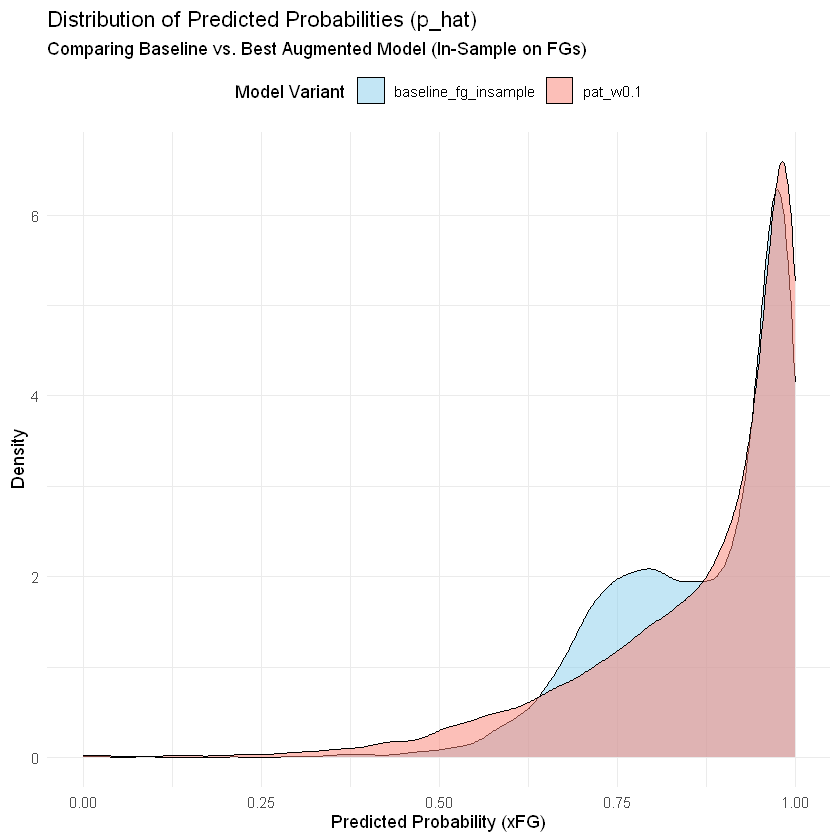

In [231]:
# --- Prediction Distribution Analysis: Best V2 Variant vs. Baseline ---

# This cell identifies the best-performing variant from the "v2" experiments
# by reading the saved metrics file. It then loads the pre-saved prediction
# files for both the best variant and the baseline to plot and compare their
# prediction distributions without re-running any models.

# 1. --- Setup and Prerequisites ---
if (!"ggplot2" %in% installed) install.packages("ggplot2")
suppressPackageStartupMessages(library(ggplot2))

# Define paths for the metrics and prediction files
metrics_path <- file.path(augmented_reports_dir, "pseudo_labelling_metrics.csv")
output_subdir_v2 <- file.path(augmented_reports_dir, "custom_variant_results_v2")
baseline_preds_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_predictions.csv')

# Check that necessary files exist
if (!file.exists(metrics_path)) {
  stop("The main metrics file 'pseudo_labelling_metrics.csv' does not exist. Please run the experiment cell first.")
}
if (!file.exists(baseline_preds_path)) {
  stop("The baseline predictions file 'baseline_fg_insample_predictions.csv' does not exist. Please run the baseline cell first.")
}


# 2. --- Identify the Best Performing V2 Variant from Saved Metrics---
cat("--- Step 1: Identifying the best performing V2 variant by AUC ---\n")

all_metrics <- readr::read_csv(metrics_path, show_col_types = FALSE)

best_variant_info <- all_metrics %>%
  dplyr::filter(variant != "baseline_fg_only") %>% # Exclude baseline from candidates
  dplyr::arrange(desc(auc)) %>%
  dplyr::slice(1)

if (nrow(best_variant_info) == 0) {
  stop("No augmented variants found in the metrics file. Please run at least one experiment.")
}

best_variant_id <- best_variant_info$variant
cat(sprintf(" -> Best variant found: '%s' (AUC: %.4f)\n", best_variant_id, best_variant_info$auc))


# 3. --- Load Pre-Saved Predictions for Best Variant and Baseline ---
cat("\n--- Step 2: Loading pre-saved predictions ---\n")

# Path for the best variant's prediction file
best_variant_preds_path <- file.path(output_subdir_v2, paste0(best_variant_id, "_predictions.csv"))

if (!file.exists(best_variant_preds_path)) {
  stop(sprintf("Prediction file for the best variant '%s' not found.", best_variant_id))
}

# Load baseline predictions (it only contains FG data)
baseline_preds_df <- readr::read_csv(baseline_preds_path, show_col_types = FALSE) %>%
  # The baseline script saves the variant name as 'model_variant', so we rename for consistency
  dplyr::rename(variant = model_variant)

# Load best variant's predictions and filter for FG data only
best_preds_df <- readr::read_csv(best_variant_preds_path, show_col_types = FALSE) %>%
  dplyr::filter(src == "FG")

# Combine for plotting
plot_data <- dplyr::bind_rows(best_preds_df, baseline_preds_df) %>%
  dplyr::filter(is.finite(p_hat))


# 4. --- Plot the Prediction Distributions ---
cat("\n--- Step 3: Plotting prediction distributions ---\n")

# Plot 1: Overlaid density plots
p1 <- ggplot(plot_data, aes(x = p_hat, fill = variant)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c("skyblue", "salmon")) +
  labs(
    title = "Distribution of Predicted Probabilities (p_hat)",
    subtitle = "Comparing Baseline vs. Best Augmented Model (In-Sample on FGs)",
    x = "Predicted Probability (xFG)",
    y = "Density",
    fill = "Model Variant"
  ) +
  theme_minimal() +
  theme(legend.position = "top")

print(p1)


In [229]:
# --- Analysis of Prediction Changes (Best V2 Variant vs. Baseline) ---

# This cell identifies the best-performing variant, loads the pre-saved
# prediction files for it and the IN-SAMPLE baseline, and then analyzes the specific
# predictions that changed between the models at a 0.5 threshold.

# 1. --- Prerequisites and File Paths ---
# This analysis now loads data directly from saved files.

# Define paths for the metrics and prediction files
metrics_path <- file.path(augmented_reports_dir, "pseudo_labelling_metrics.csv")
output_subdir_v2 <- file.path(augmented_reports_dir, "custom_variant_results_v2")
insample_baseline_preds_path <- file.path(augmented_reports_dir, 'baseline_fg_insample_predictions.csv')

# Check that necessary files exist
if (!file.exists(metrics_path)) {
  stop("The main metrics file 'pseudo_labelling_metrics.csv' does not exist. Please run the experiment cell first.")
}
if (!file.exists(insample_baseline_preds_path)) {
  stop("The baseline predictions file 'baseline_fg_insample_predictions.csv' does not exist. Please run the baseline cell first.")
}

# 2. --- Identify Best Variant and Load Predictions ---
cat("--- Step 1: Identifying best variant and loading predictions ---\n")

# Find the best-performing variant from the saved metrics file
all_metrics <- readr::read_csv(metrics_path, show_col_types = FALSE)
best_variant_info <- all_metrics %>%
  dplyr::filter(variant != "baseline_fg_insample") %>% # Exclude the IN-SAMPLE baseline
  dplyr::arrange(desc(auc)) %>%
  dplyr::slice(1)

if (nrow(best_variant_info) == 0) {
  stop("No augmented variants found in the metrics file. Please run at least one experiment.")
}
best_variant_id <- best_variant_info$variant
cat(sprintf(" -> Best variant found: '%s' (AUC: %.4f)\n", best_variant_id, best_variant_info$auc))

# Load IN-SAMPLE baseline predictions
# The baseline script saves the variant name as 'model_variant', so we rename for consistency
baseline_preds_df <- readr::read_csv(insample_baseline_preds_path, show_col_types = FALSE) %>%
  dplyr::rename(variant = model_variant)

# Load the best variant's predictions and filter for FG data only
best_variant_preds_path <- file.path(output_subdir_v2, paste0(best_variant_id, "_predictions.csv"))
if (!file.exists(best_variant_preds_path)) {
  stop(sprintf("Prediction file for the best variant '%s' not found.", best_variant_id))
}
best_preds_df <- readr::read_csv(best_variant_preds_path, show_col_types = FALSE) %>%
  dplyr::filter(src == "FG")

# Combine the two prediction sets
combined_preds <- dplyr::bind_rows(best_preds_df, baseline_preds_df)

# 3. --- Prepare Data for Change Analysis ---
cat("--- Step 2: Preparing data for change analysis ---\n")

# Add a unique identifier for each kick to ensure correct pivoting
combined_preds_with_id <- combined_preds %>%
  dplyr::group_by(variant) %>%
  dplyr::mutate(kick_id = dplyr::row_number()) %>%
  dplyr::ungroup()

# Pivot the data to have one row per kick, with columns for each model's prediction
comparison_df <- combined_preds_with_id %>%
  tidyr::pivot_wider(
    id_cols = c(kick_id, kick_made), # Use kick_id to uniquely identify rows
    names_from = variant,
    values_from = p_hat
  ) %>%
  # Ensure the column name for the best model is syntactically valid
  dplyr::rename(p_hat_best = !!best_variant_id, p_hat_base = baseline_fg_insample)

# Create binary class predictions based on a 0.5 threshold
change_analysis_df <- comparison_df %>%
  dplyr::mutate(
    pred_base = ifelse(p_hat_base >= 0.5, 1, 0),
    pred_best = ifelse(p_hat_best >= 0.5, 1, 0),
    # Flag if the prediction changed
    prediction_changed = (pred_base != pred_best)
  )

# 4. --- Analyze and Display the Changed Predictions ---
cat("--- Step 3: Analyzing and summarizing changed predictions ---\n")

changed_predictions <- change_analysis_df %>%
  dplyr::filter(prediction_changed == TRUE) %>%
  dplyr::mutate(
    change_type = dplyr::case_when(
      pred_base == 0 & pred_best == 1 ~ "Flipped Miss to Make",
      pred_base == 1 & pred_best == 0 ~ "Flipped Make to Miss",
      TRUE ~ "No Change"
    ),
    is_correct_change = (pred_best == kick_made)
  )

# Summarize the changes
change_summary <- changed_predictions %>%
  dplyr::group_by(change_type, is_correct_change) %>%
  dplyr::summarise(count = n(), .groups = "drop") %>%
  tidyr::pivot_wider(
    names_from = is_correct_change,
    values_from = count,
    values_fill = 0,
    names_prefix = "change_was_"
  ) %>%
  dplyr::rename(
    correct_changes = `change_was_TRUE`,
    incorrect_changes = `change_was_FALSE`
  )

total_changed = sum(change_summary$correct_changes) + sum(change_summary$incorrect_changes)
total_obs = nrow(change_analysis_df)

# Display the Summary
cat("\n--- Summary of Prediction Changes at 0.5 Threshold ---\n")
cat(sprintf("Total Observations: %d\n", total_obs))
cat(sprintf("Total Predictions Changed: %d (%.2f%% of total)\n\n", total_changed, (total_changed / total_obs) * 100))

if (total_changed > 0) {
  print(change_summary)
  
  net_correct_changes <- sum(change_summary$correct_changes) - sum(change_summary$incorrect_changes)
  
  cat("\n--- Interpretation ---\n")
  cat(sprintf("The augmented model made a total of %d correct changes and %d incorrect changes.\n",
              sum(change_summary$correct_changes), sum(change_summary$incorrect_changes)))
  cat(sprintf("This resulted in a net gain/loss of %d correctly classified kicks.\n", net_correct_changes))
  
  # Detailed breakdown
  flipped_to_make <- change_summary %>% dplyr::filter(change_type == "Flipped Miss to Make")
  if (nrow(flipped_to_make) > 0) {
    cat(sprintf("- Of kicks flipped to MAKE: %d were correct (actual makes), %d were incorrect (actual misses).\n", 
                flipped_to_make$correct_changes, flipped_to_make$incorrect_changes))
  }
  
  flipped_to_miss <- change_summary %>% dplyr::filter(change_type == "Flipped Make to Miss")
  if (nrow(flipped_to_miss) > 0) {
    cat(sprintf("- Of kicks flipped to MISS: %d were correct (actual misses), %d were incorrect (actual makes).\n", 
                flipped_to_miss$correct_changes, flipped_to_miss$incorrect_changes))
  }
  
} else {
  cat("No predictions changed between the two models at the 0.5 threshold.\n")
}


--- Step 1: Identifying best variant and loading predictions ---
 -> Best variant found: 'pat_w0.1' (AUC: 0.8371)
--- Step 2: Preparing data for change analysis ---
--- Step 3: Analyzing and summarizing changed predictions ---

--- Summary of Prediction Changes at 0.5 Threshold ---
Total Observations: 10432
Total Predictions Changed: 292 (2.80% of total)

# A tibble: 2 × 3
  change_type          incorrect_changes correct_changes
  <chr>                            <int>           <int>
1 Flipped Make to Miss               108             171
2 Flipped Miss to Make                 9               4

--- Interpretation ---
The augmented model made a total of 175 correct changes and 117 incorrect changes.
This resulted in a net gain/loss of 58 correctly classified kicks.
- Of kicks flipped to MAKE: 4 were correct (actual makes), 9 were incorrect (actual misses).
- Of kicks flipped to MISS: 171 were correct (actual misses), 108 were incorrect (actual makes).



--- Generating Plot 1: Calibration by Kick Distance ---
Saved distance calibration plot to G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/calibration_plots/calib_by_distance.png

--- Generating Plot 2: Calibration by Predicted Probability ---


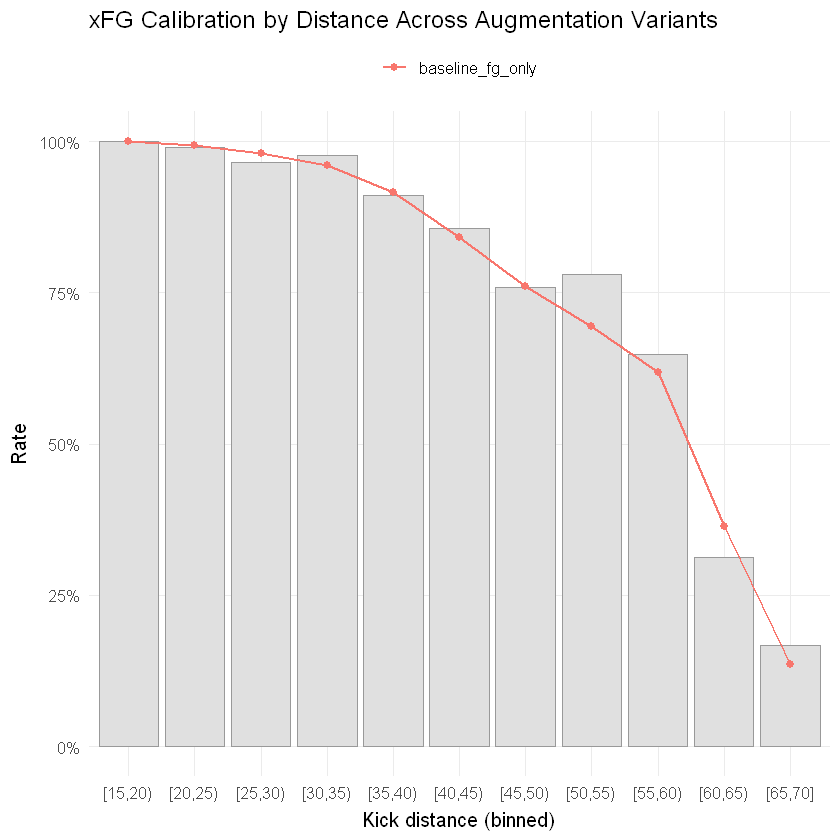

Saved probability calibration plot to G:\My files\Python\Sports Analytics Projects\Football\Kickers\NFL-Field-Goal-Kicker-Model/reports/xfg_success_augmented/calibration_plots/calib_by_probability.png

--- Generating Plot 3: Calibration Slopes ---


ERROR: [1m[33mError[39m in `dplyr::reframe()`:[22m
[1m[22m[36mℹ[39m In argument: `get_cal_slope(.data)`.
[36mℹ[39m In group 1: `variant = "baseline_fg_only"`.
[1mCaused by error in `UseMethod()`:[22m
[33m![39m no applicable method for 'filter' applied to an object of class "rlang_data_pronoun"


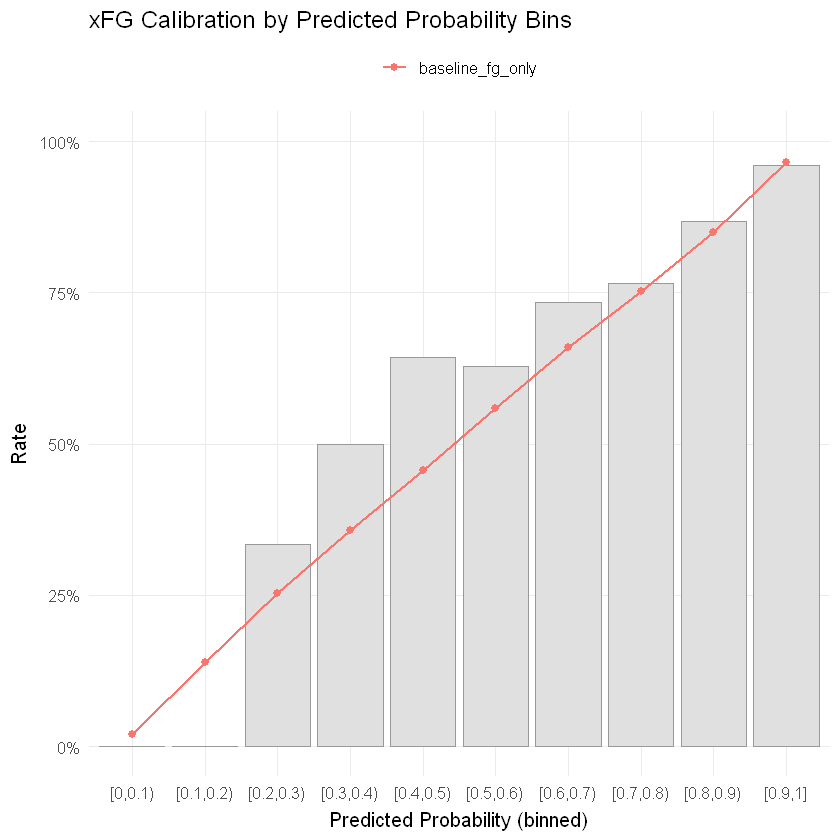

In [141]:
# --- Comprehensive Calibration Analysis for All Variants ---

output_dir <- file.path(augmented_reports_dir, 'calibration_plots')
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

# Add baseline predictions to the list for consistency
baseline_preds <- tibble::tibble(
  variant = "baseline_fg_only",
  kick_made = test_fg$kick_made,
  kick_distance = test_fg$kick_distance,
  p_hat = p_base
)
all_predictions <- c(list(baseline_preds), all_predictions)

# Combine predictions from all augmented variants with the baseline
all_predictions_df <- dplyr::bind_rows(all_predictions) %>%
  dplyr::filter(!is.na(p_hat), is.finite(p_hat), !is.na(kick_distance))

# --- Plot 1: Calibration by Kick Distance ---
cat("\n--- Generating Plot 1: Calibration by Kick Distance ---\n")

# Use `make_calib_by_dist` for each variant and combine
calib_by_dist <- all_predictions_df %>%
  dplyr::group_by(variant) %>%
  dplyr::group_modify(~ make_calib_by_dist(., p_col = "p_hat", dist_col = "kick_distance")) %>%
  dplyr::ungroup() %>%
  dplyr::rename(model = variant)

dist_plot <- calib_compare_plot(
  calib_by_dist,
  title = "xFG Calibration by Distance Across Augmentation Variants",
  show_bars = TRUE
)
print(dist_plot)
ggsave(file.path(output_dir, "calib_by_distance.png"), dist_plot, width = 12, height = 8, dpi = 300)
cat(sprintf("Saved distance calibration plot to %s\n", file.path(output_dir, "calib_by_distance.png")))


# --- Plot 2: Calibration by Predicted Probability ---
cat("\n--- Generating Plot 2: Calibration by Predicted Probability ---\n")

# Use `make_calib_by_dist`, but bin by `p_hat` instead of `kick_distance`
calib_by_prob <- all_predictions_df %>%
  dplyr::group_by(variant) %>%
  dplyr::group_modify(~ make_calib_by_dist(., p_col = "p_hat", dist_col = "p_hat", breaks = seq(0, 1, by = 0.1))) %>%
  dplyr::ungroup() %>%
  dplyr::rename(model = variant)

prob_plot <- calib_compare_plot(
  calib_by_prob,
  title = "xFG Calibration by Predicted Probability Bins",
  show_bars = TRUE
) + labs(x = "Predicted Probability (binned)") # Relabel x-axis
print(prob_plot)
ggsave(file.path(output_dir, "calib_by_probability.png"), prob_plot, width = 12, height = 8, dpi = 300)
cat(sprintf("Saved probability calibration plot to %s\n", file.path(output_dir, "calib_by_probability.png")))


# --- Plot 3: Calibration Slope Scores ---
cat("\n--- Generating Plot 3: Calibration Slopes ---\n")

cal_slopes <- all_predictions_df %>%
  dplyr::group_by(variant) %>%
  dplyr::reframe(get_cal_slope(.data)) %>%
  dplyr::rename(model = variant) %>%
  dplyr::mutate(treatment = "Augmented") # Dummy column for the plot function

# Use the existing `slope_bar_plot` function
slope_plot <- slope_bar_plot(
    cal_slopes,
    title = "Calibration Slopes for Augmentation Variants"
) + theme(legend.position = "none")
print(slope_plot)
ggsave(file.path(output_dir, "calib_slopes.png"), slope_plot, width = 10, height = 6, dpi = 300)
cat(sprintf("Saved calibration slope plot to %s\n", file.path(output_dir, "calib_slopes.png")))